(mmm_pareto_optimization)=
# Pareto Optimization Across Products with a Shared Media Budget

Most budget optimizations in an MMM maximize one number: total revenue, total conversions, one product's sales. In practice one media budget often serves several products at once, and each channel helps them differently. A channel that drives product A can be close to useless for product B. Then there is no single best plan, only a set of trade-offs, and the question becomes which trade-off to pick and how to defend it.

This notebook works through that situation on synthetic data, where we know the true response curves and can check every step:

1. **Data.** Five shared media channels, three products and three outcomes (`sales`, `consideration`, `brand`) over $100$ weeks. One vectorized `pymc.dims` model generates all nine outcome series at once.
2. **The trade-off.** With the true parameters we trace the Pareto frontier between the products and pick a balanced allocation with a max-min rule.
3. **Fit and recover.** We fit the model, check the sampler diagnostics, and confirm that it recovers the channel contributions.
4. **Five priorities, one budget.** Using the posterior, we optimize the same weekly budget for five different business priorities and compare what each of them buys.
5. **Spillover.** We extend the model so that product A's media can lift product B's consideration, fit it, and re-optimize.
6. **Goals instead of a budget.** We turn the question around: what is the cheapest plan that reaches given sales and consideration goals for product B?

```{note}
This notebook combines three tools shown elsewhere in the documentation: custom utilities and constraints for {class}`~pymc_marketing.mmm.budget_optimizer.BudgetOptimizer` from {ref}`mmm_multi_objective_optimization` and {ref}`mmm_budget_allocation_example`, and masked cross-product effects from {ref}`mmm_halo`. The model is written directly in `pymc.dims`; {ref}`mmm_dims_migration_guide` explains the notation.
```

## Prepare Notebook

In [1]:
import warnings
from collections.abc import Callable

import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import seaborn as sns
import xarray as xr
from matplotlib.tri import Triangulation
from pymc.model.fgraph import clone_model
from pymc_extras.prior import Prior
from pytensor.xtensor.type import XTensorVariable
from scipy.optimize import minimize

from pymc_marketing.mmm import GeometricAdstock, MichaelisMentenSaturation
from pymc_marketing.mmm.budget_optimizer import (
    BudgetOptimizationResult,
    BudgetOptimizer,
)
from pymc_marketing.mmm.constraints import Constraint
from pymc_marketing.special_priors import MaskedPrior

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="This class is experimental")

az.style.use("arviz-darkgrid")
HDI_PROB = 0.94
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = "retina"

In [2]:
seed: int = sum(map(ord, "mmm_pareto_optimization"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## Synthetic Data

### Shared channel spend

We simulate $100$ weeks of spend for five channels. The spend is *shared*: there is one series per channel, not one per product. Two channels run as short campaigns, `out of home` in weeks $11$ to $19$ and `social media` in weeks $10$ to $19$; the other three are on every week. All amounts are in the same monetary unit, and typical weekly spend per channel is around $1{,}000$.

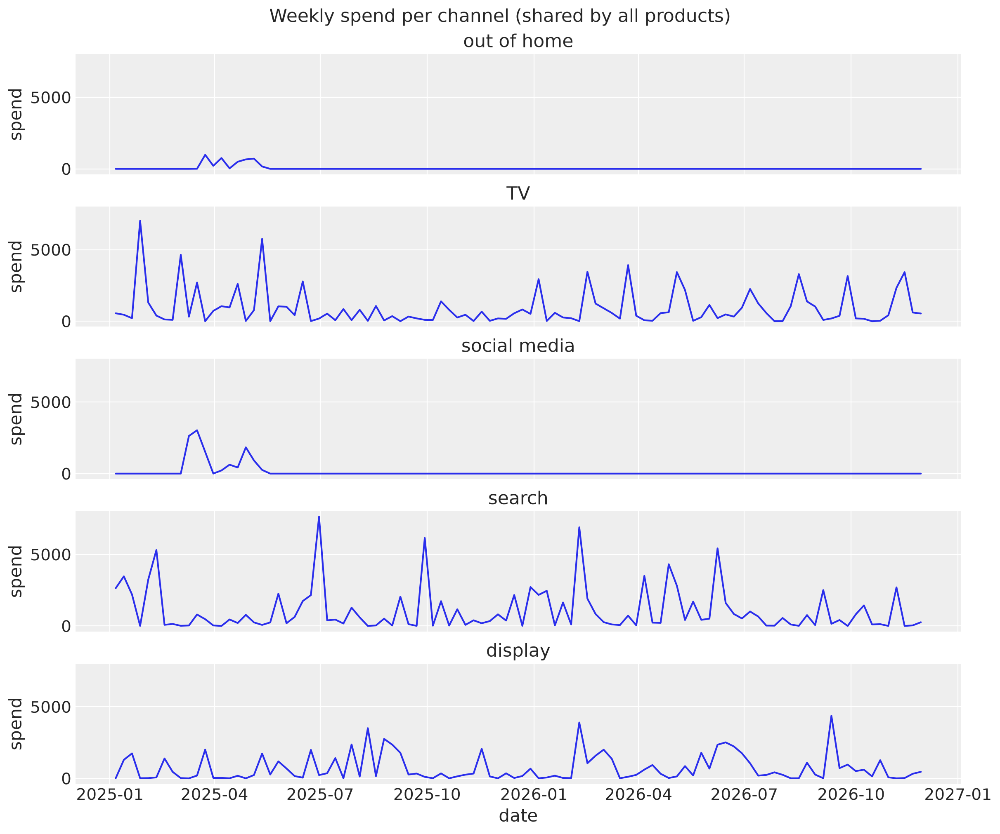

In [3]:
dates = pd.date_range("2025-01-06", periods=100, freq="W-MON")
products = ["product A", "product B", "product C"]
channels = ["out of home", "TV", "social media", "search", "display"]
targets = ["sales", "consideration", "brand"]
unit_scale = 1_000.0

week = xr.DataArray(np.arange(1, len(dates) + 1), dims="date", coords={"date": dates})
launch_week = xr.DataArray(
    [11, 1, 10, 1, 1], dims="channel", coords={"channel": channels}
)
stop_week = xr.DataArray(
    [20, 101, 20, 101, 101], dims="channel", coords={"channel": channels}
)
active_weeks = (week >= launch_week) & (week < stop_week)

channel_values = xr.DataArray(
    rng.gamma(shape=0.5, scale=2.0 * unit_scale, size=(len(dates), len(channels))),
    dims=("date", "channel"),
    coords={"date": dates, "channel": channels},
    name="channel_data",
).where(active_weeks, 0.0)

fig, axes = plt.subplots(
    nrows=len(channels),
    ncols=1,
    figsize=(12, 10),
    sharex=True,
    sharey=True,
    layout="constrained",
)
for ax, channel in zip(axes, channels, strict=True):
    ax.plot(channel_values.date, channel_values.sel(channel=channel), color="C0")
    ax.set(title=channel, ylabel="spend")
axes[-1].set(xlabel="date")
fig.suptitle("Weekly spend per channel (shared by all products)", fontsize=16);

The series are drawn independently, so most correlations are small. The exception is `out of home` and `social media`: they share their ten active weeks and are zero elsewhere, which gives them a correlation of about $0.44$ by construction. Correlated inputs make channel effects harder to separate; that matters for the fit, and we will meet it again when we let these two channels spill over between products.

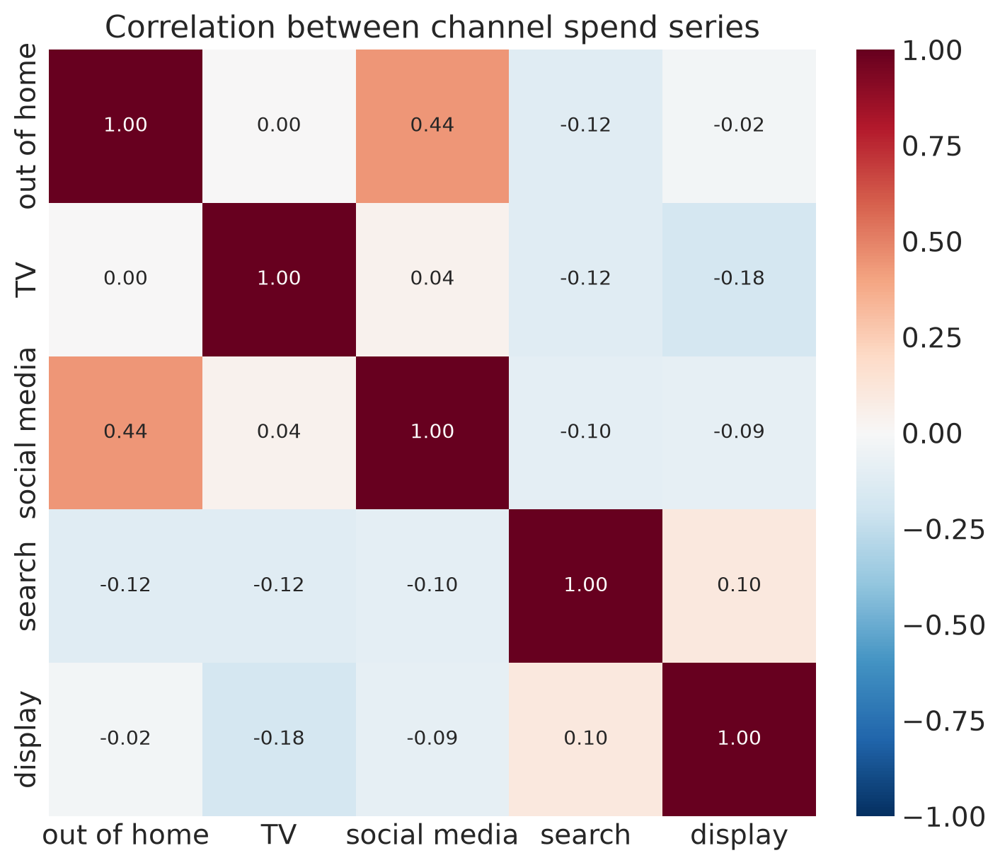

In [4]:
channel_correlations = xr.corr(
    channel_values, channel_values.rename(channel="other_channel"), dim="date"
)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    channel_correlations.to_pandas(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax,
)
ax.set(title="Correlation between channel spend series", xlabel="", ylabel="");

### One model for all products and outcomes

Every channel reaches every product, but with its own response curve for each product and each outcome. For product $p$, outcome $k$ and channel $c$, the model applies a geometric adstock with $L = 7$ lags and normalized weights, then a Michaelis-Menten saturation:

$$
z_{t,p,k,c} = \frac{\sum_{\ell=0}^{6}\rho_{p,k,c}^{\ell}\,x_{t-\ell,c}}{\sum_{\ell=0}^{6}\rho_{p,k,c}^{\ell}},
\qquad
f_{t,p,k,c} = A_{p,k,c}\,\frac{z_{t,p,k,c}}{\lambda_{p,k,c} + z_{t,p,k,c}},
\qquad
\mu_{t,p,k} = a_{p,k} + \sum_{c} f_{t,p,k,c},
\qquad
y_{t,p,k} \sim \mathcal{N}(\mu_{t,p,k}, \sigma_{p,k}).
$$

The spend $x_{t,c}$ has no product index. `pymc.dims` broadcasts it against parameters with dims `(product, target, channel)` by name, so we never replicate the spend array by hand. The nine outcome series share one vectorized Normal likelihood with dims `(date, product, target)`.

Spend and outcomes are in the thousands. Inside the model we divide spend by `unit_scale = 1,000`, so that the saturation parameters are of order one and their priors are easy to set, and multiply the response back. All budgets, tables and plots in the notebook are in the original units. One prior deserves a comment: the half-saturation $\lambda$ gets a $\operatorname{Gamma}(\mu=1, \sigma=0.5)$ prior, that is, half-saturation around $1{,}000$ spend units. A prior that allows $\lambda \approx 0$ lets an always-on channel act as a constant, which the model cannot tell apart from the intercept.

The `target_data` container starts as zeros. We only need the graph at this point; the simulated outcomes go in below.

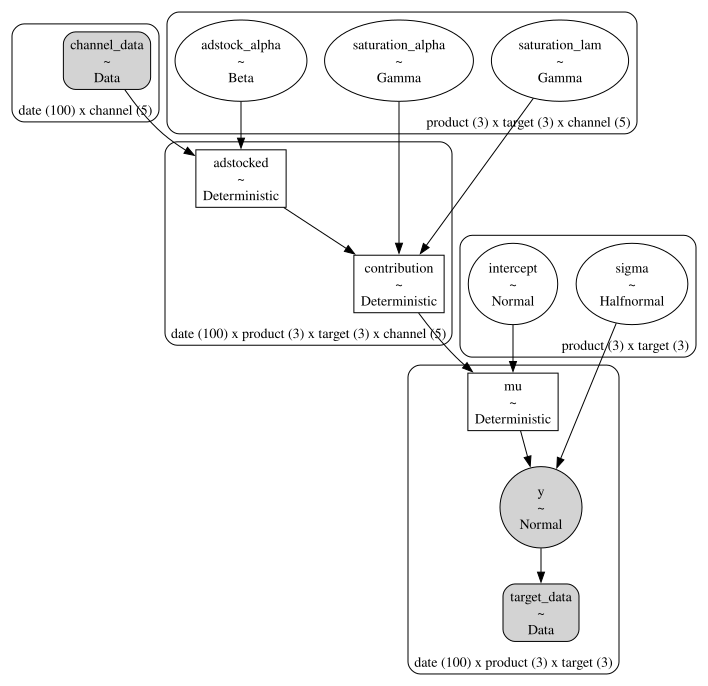

In [5]:
coordinates = {
    "date": dates,
    "channel": channels,
    "product": products,
    "target": targets,
}
parameter_dims = ("product", "target", "channel")
target_values = xr.DataArray(
    np.zeros((len(dates), len(products), len(targets))),
    dims=("date", "product", "target"),
    coords={dim: coordinates[dim] for dim in ("date", "product", "target")},
    name="target_data",
)

adstock = GeometricAdstock(
    l_max=7,
    normalize=True,
    priors={"alpha": Prior("Beta", alpha=2, beta=2, dims=parameter_dims)},
)
saturation = MichaelisMentenSaturation(
    priors={
        "alpha": Prior("Gamma", mu=2, sigma=1, dims=parameter_dims),
        "lam": Prior("Gamma", mu=1, sigma=0.5, dims=parameter_dims),
    },
)


def build_base_model() -> pm.Model:
    """Build the vectorized adstock-saturation model for all products and outcomes."""
    with pm.Model(coords=coordinates) as model:
        channel_data = pmd.Data("channel_data", channel_values)
        target_data = pmd.Data("target_data", target_values)
        adstocked = pmd.Deterministic(
            "adstocked",
            adstock.apply(channel_data / unit_scale, core_dim="date"),
            dims=("date", "product", "target", "channel"),
        )
        contribution = pmd.Deterministic(
            "contribution",
            unit_scale * saturation.apply(adstocked),
            dims=("date", "product", "target", "channel"),
        )
        intercept = Prior(
            "Normal", mu=1, sigma=1, dims=("product", "target")
        ).create_variable("intercept", xdist=True)
        sigma = Prior(
            "HalfNormal", sigma=0.2, dims=("product", "target")
        ).create_variable("sigma", xdist=True)
        mu = pmd.Deterministic(
            "mu",
            unit_scale * intercept + contribution.sum(dim="channel"),
            dims=("date", "product", "target"),
        )
        pmd.Normal(
            "y",
            mu=mu,
            sigma=unit_scale * sigma,
            observed=target_data,
            dims=("date", "product", "target"),
        )
    return model


base_model = build_base_model()
pm.model_to_graphviz(base_model)

### True parameters and simulated outcomes

We fix the parameters with `pm.do` and draw the outcomes. The sales amplitudes encode the conflict we want to study: product A's sales respond to `out of home` and `TV`, product B's sales respond to `search` and `display`, and product C sits in between. Consideration leans towards `search` and `display` for all three products.

For sales we use the same decay and half-saturation for every product, so the sales trade-off between products comes only from the amplitudes and is easy to read. The other parameters are drawn at random within sensible ranges. The model does not know any of this: it estimates a separate set of parameters for every product, outcome and channel.

`brand` is a copy of `consideration`: same intercept, same response curves, but twice the observation noise. Think of a survey-based brand metric that tracks the same underlying demand as consideration, only more noisily. We keep it to see what noise alone does to an optimized allocation.

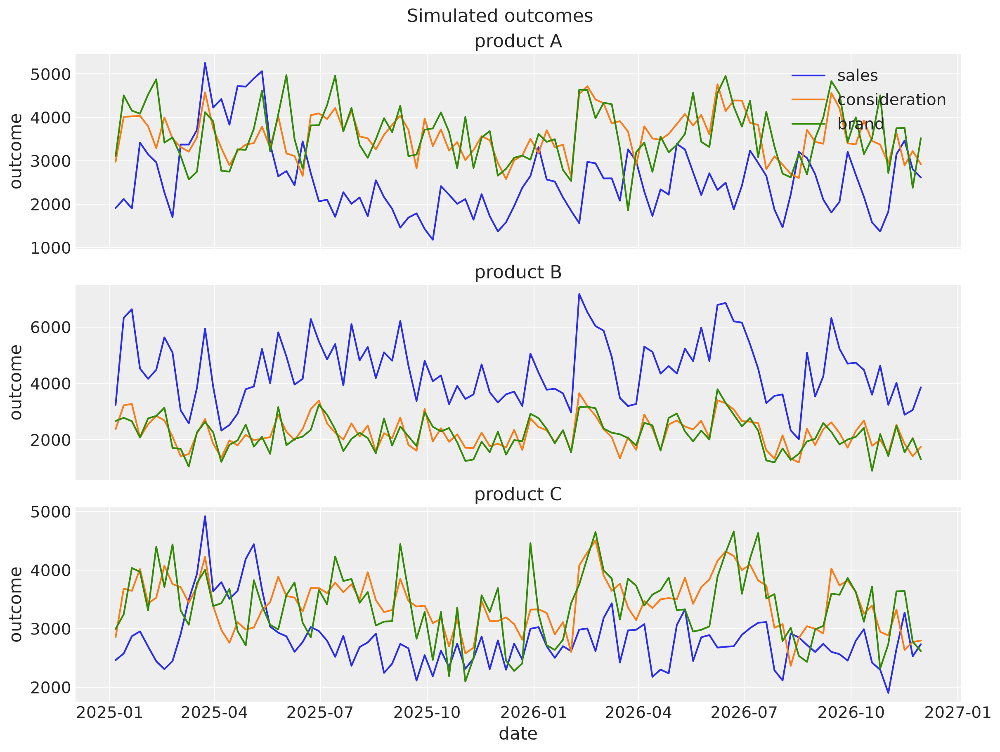

In [6]:
true_parameters = {
    "saturation_alpha": np.stack(
        [
            # sales: product A -> out of home and TV; product B -> search and display
            np.array(
                [
                    [4.0, 3.0, 0.8, 0.05, 0.05],
                    [0.05, 0.05, 0.8, 3.0, 4.0],
                    [1.8, 1.0, 1.2, 0.4, 0.2],
                ]
            ),
            # consideration: all products lean towards search and display
            np.array(
                [
                    [0.2, 0.3, 0.8, 1.5, 2.0],
                    [0.4, 0.2, 0.6, 2.2, 1.2],
                    [0.1, 0.5, 1.0, 1.4, 1.8],
                ]
            ),
        ],
        axis=1,
    ),
    "adstock_alpha": rng.uniform(0.2, 0.7, size=(len(products), 2, len(channels))),
    "saturation_lam": rng.uniform(0.5, 1.5, size=(len(products), 2, len(channels))),
    "intercept": np.array([[1.0, 2.0], [1.5, 1.0], [2.0, 1.5]]),
    "sigma": np.array([[0.15, 0.25], [0.20, 0.15], [0.25, 0.20]]),
}
# Sales share the decay and half-saturation across products: the trade-off comes from the amplitudes only.
true_parameters["adstock_alpha"][:, 0, :] = [0.25, 0.4, 0.35, 0.4, 0.25]
true_parameters["saturation_lam"][:, 0, :] = 0.8
# Brand copies consideration, with twice the observation noise.
for name, values in true_parameters.items():
    brand_values = values[:, 1:2] * (2.0 if name == "sigma" else 1.0)
    true_parameters[name] = np.concatenate([values, brand_values], axis=1)

generative_model = pm.do(base_model, true_parameters)
true_mu_values, true_contribution_values, observed_values = pm.draw(
    [generative_model["mu"], generative_model["contribution"], generative_model["y"]],
    random_seed=seed,
)
true_mu = xr.DataArray(
    true_mu_values,
    dims=("date", "product", "target"),
    coords={dim: coordinates[dim] for dim in ("date", "product", "target")},
)
true_contribution = xr.DataArray(
    true_contribution_values,
    dims=("date", "product", "target", "channel"),
    coords=coordinates,
)
target_values = xr.DataArray(
    observed_values,
    dims=("date", "product", "target"),
    coords={dim: coordinates[dim] for dim in ("date", "product", "target")},
    name="target_data",
)
with base_model:
    pm.set_data({"target_data": target_values.values})

fig, axes = plt.subplots(
    nrows=len(products), ncols=1, figsize=(12, 9), sharex=True, layout="constrained"
)
for ax, product in zip(axes, products, strict=True):
    for j, target in enumerate(targets):
        ax.plot(
            dates,
            target_values.sel(product=product, target=target),
            color=f"C{j}",
            label=target,
        )
    ax.set(title=product, ylabel="outcome")
axes[0].legend(loc="upper right")
axes[-1].set(xlabel="date")
fig.suptitle("Simulated outcomes", fontsize=16);

The brand series follow consideration closely, with more scatter. The table confirms the construction: the residual standard deviation around the true mean is about twice as large for brand.

,correlation,consideration residual sd,brand residual sd
product,,,
product A,0.58,234.98,509.57
product B,0.83,136.86,299.69
product C,0.66,178.35,454.93


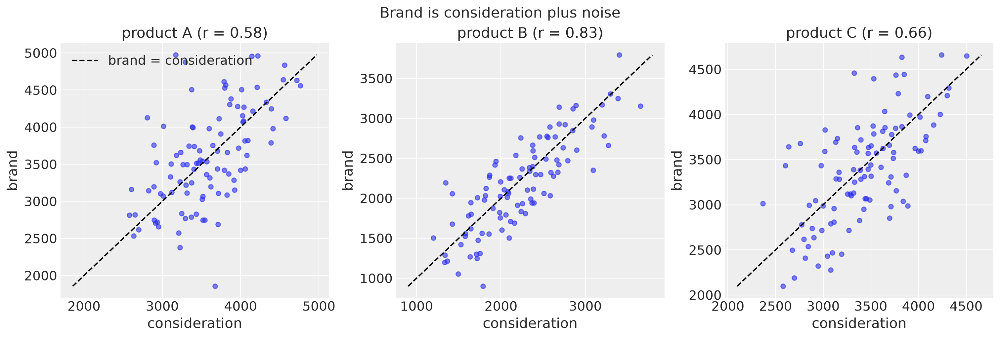

In [7]:
brand_relationship_rows = []
fig, axes = plt.subplots(
    nrows=1, ncols=len(products), figsize=(15, 5), layout="constrained"
)
for product_index, (ax, product) in enumerate(zip(axes, products, strict=True)):
    consideration_observed = target_values.sel(
        product=product, target="consideration"
    ).values
    brand_observed = target_values.sel(product=product, target="brand").values
    correlation = np.corrcoef(consideration_observed, brand_observed)[0, 1]
    limits = np.array(
        [
            min(consideration_observed.min(), brand_observed.min()),
            max(consideration_observed.max(), brand_observed.max()),
        ]
    )
    ax.scatter(consideration_observed, brand_observed, color="C0", alpha=0.6, s=25)
    ax.plot(
        limits, limits, color="black", linestyle="--", label="brand = consideration"
    )
    ax.set(
        title=f"{product} (r = {correlation:.2f})",
        xlabel="consideration",
        ylabel="brand",
    )
    brand_relationship_rows.append(
        {
            "product": product,
            "correlation": correlation,
            "consideration residual sd": np.std(
                consideration_observed - true_mu_values[:, product_index, 1], ddof=1
            ),
            "brand residual sd": np.std(
                brand_observed - true_mu_values[:, product_index, 2], ddof=1
            ),
        }
    )
axes[0].legend(loc="upper left")
fig.suptitle("Brand is consideration plus noise", fontsize=16)
pd.DataFrame(brand_relationship_rows).set_index("product").round(2)

## The Trade-off Between Products

### A first look: moving budget between channel groups

Before fitting anything, we look at the conflict in the true model. We fix a weekly budget of $5{,}000$ and move it between the two channel groups: at one end all of it goes to `search` and `display` (product B's channels), at the other end to `out of home` and `TV` (product A's channels). `social media` keeps a fifth of the budget throughout.

With normalized adstock, a constant weekly allocation reaches its steady state after $7$ weeks, and the steady-state response is just the saturation curve evaluated at that allocation. So we can compute the media-driven sales of each product directly from the parameters, without simulating weeks.

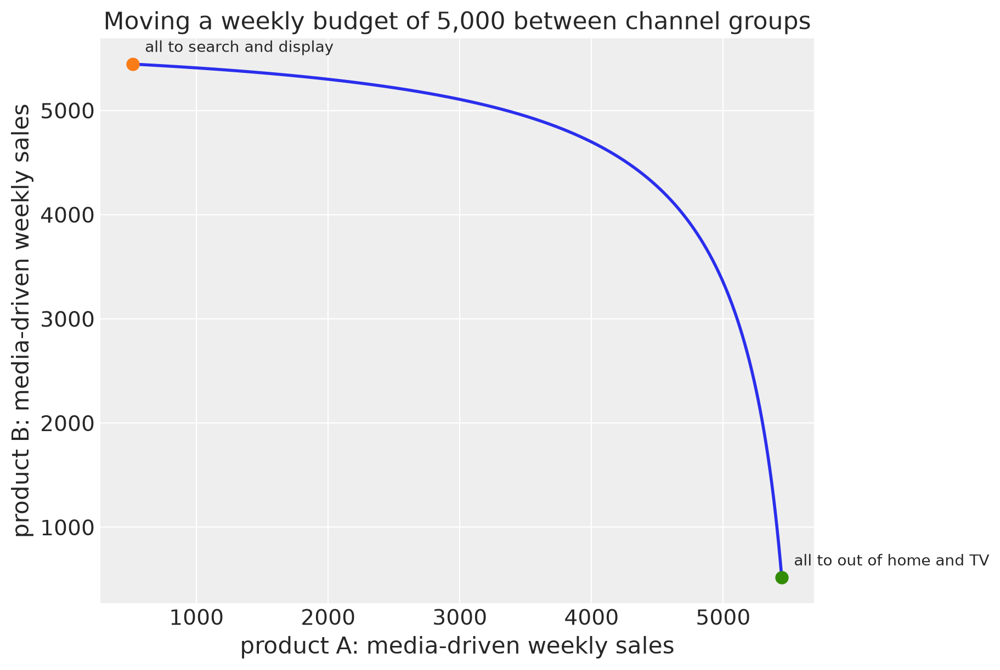

In [8]:
weekly_budget = 5.0 * unit_scale
allocation_fraction = np.linspace(0.0, 1.0, 101)
allocation_sweep = xr.DataArray(
    np.column_stack(
        [
            0.4 * weekly_budget * allocation_fraction,
            0.4 * weekly_budget * allocation_fraction,
            np.full_like(allocation_fraction, 0.2 * weekly_budget),
            0.4 * weekly_budget * (1.0 - allocation_fraction),
            0.4 * weekly_budget * (1.0 - allocation_fraction),
        ]
    ),
    dims=("allocation", "channel"),
    coords={"allocation": allocation_fraction, "channel": channels},
)
true_maximum = xr.DataArray(
    unit_scale * true_parameters["saturation_alpha"],
    dims=parameter_dims,
    coords={dim: coordinates[dim] for dim in parameter_dims},
)
true_half_saturation = xr.DataArray(
    unit_scale * true_parameters["saturation_lam"],
    dims=parameter_dims,
    coords={dim: coordinates[dim] for dim in parameter_dims},
)
sweep_response = (
    true_maximum * allocation_sweep / (true_half_saturation + allocation_sweep)
).sum("channel")
response_a = sweep_response.sel(product="product A", target="sales")
response_b = sweep_response.sel(product="product B", target="sales")

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(response_a, response_b, color="C0", linewidth=2)
for fraction, label, color in [
    (0.0, "all to search and display", "C1"),
    (1.0, "all to out of home and TV", "C2"),
]:
    x = response_a.sel(allocation=fraction).item()
    y = response_b.sel(allocation=fraction).item()
    ax.scatter(x, y, s=60, color=color, zorder=3)
    ax.annotate(label, (x, y), xytext=(8, 8), textcoords="offset points")
ax.set(
    xlabel="product A: media-driven weekly sales",
    ylabel="product B: media-driven weekly sales",
    title=f"Moving a weekly budget of {weekly_budget:,.0f} between channel groups",
);

The curve is bent: because of saturation, the first units moved away from a product's best channels cost it little, and the last units cost it a lot. This is what makes a balanced allocation attractive rather than a corner solution.

### Pareto frontiers for three products

The sweep only moves budget along one line. Now we optimize all five channel budgets, still summing to $5{,}000$ per week, for all three products at once. There is no single optimum; there is a *frontier* of allocations where improving one product's response requires giving up some of another's. We trace it in the usual way, by maximizing weighted sums of the three responses over a grid of weights. Each response is a sum of concave saturation curves, so every point of the frontier can be reached with some set of positive weights, and the weighted-sum approach does not miss any part of it.

To pick one allocation on the frontier we use a **max-min rule**. Let $I_p$ be the best response product $p$ could get if the whole budget served it alone. We then maximize the smallest fraction of that ideal across products:

$$
\max_{b,\,t}\ t
\qquad\text{s.t.}\qquad
\frac{R_p(b)}{I_p} \geq t \ \text{ for every product } p,
\qquad b_c \geq 0,
\qquad \sum_c b_c = 5{,}000.
$$

This protects the product that is worst off *relative to its own potential*. It does not equalize raw responses, which would make little sense for products of different sizes. The helper functions below implement the response, its gradient, the weighted-sum problem and the max-min problem with `scipy.optimize.minimize` (SLSQP). They accept either one parameter set or a stack of posterior draws, which we will need later.

In [9]:
def product_response_and_gradient(
    allocation: np.ndarray, maximum: np.ndarray, half_saturation: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Compute the steady-state response per product and its gradient per channel budget.

    ``maximum`` and ``half_saturation`` have shape ``(product, channel)`` or ``(sample, product, channel)``;
    with samples, the response and gradient are averaged over the draws.
    """
    denominator = half_saturation + allocation
    response = (maximum * allocation / denominator).sum(axis=-1)
    gradient = maximum * half_saturation / denominator**2
    sample_axes = tuple(range(maximum.ndim - 2))
    if sample_axes:
        response = response.mean(axis=sample_axes)
        gradient = gradient.mean(axis=sample_axes)
    return response, gradient


def weighted_product_allocation(
    weights: np.ndarray,
    maximum: np.ndarray,
    half_saturation: np.ndarray,
    total_budget: float,
) -> np.ndarray:
    """Maximize a weighted sum of product responses at a fixed total budget."""
    n_channels = maximum.shape[-1]
    weights = weights / weights.sum()

    def objective(fractions: np.ndarray) -> tuple[float, np.ndarray]:
        response, gradient = product_response_and_gradient(
            fractions * total_budget, maximum, half_saturation
        )
        return (
            -float(weights @ response) / unit_scale,
            -(weights @ gradient) * total_budget / unit_scale,
        )

    result = minimize(
        objective,
        x0=np.full(n_channels, 1.0 / n_channels),
        jac=True,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n_channels,
        constraints=[
            {
                "type": "eq",
                "fun": lambda fractions: fractions.sum() - 1.0,
                "jac": lambda fractions: np.ones(n_channels),
            }
        ],
        options={"ftol": 1e-11, "maxiter": 500},
    )
    if not result.success:
        raise RuntimeError(f"Weighted-sum optimization failed: {result.message}")
    return result.x * total_budget


def balanced_product_allocation(
    maximum: np.ndarray,
    half_saturation: np.ndarray,
    ideal_response: np.ndarray,
    starting_budget: np.ndarray,
    total_budget: float,
) -> tuple[np.ndarray, float]:
    """Maximize the smallest fraction of each product's ideal response (max-min)."""
    n_products, n_channels = maximum.shape[-2:]

    def balance_constraints(decision: np.ndarray) -> np.ndarray:
        response, _ = product_response_and_gradient(
            decision[:-1] * total_budget, maximum, half_saturation
        )
        return response / ideal_response - decision[-1]

    def balance_constraint_gradient(decision: np.ndarray) -> np.ndarray:
        _, gradient = product_response_and_gradient(
            decision[:-1] * total_budget, maximum, half_saturation
        )
        return np.column_stack(
            [gradient * total_budget / ideal_response[:, None], -np.ones(n_products)]
        )

    starting_response, _ = product_response_and_gradient(
        starting_budget, maximum, half_saturation
    )
    # The last decision variable is the attainment level t; this makes max-min a smooth problem.
    result = minimize(
        lambda decision: -decision[-1],
        x0=np.r_[
            starting_budget / total_budget, (starting_response / ideal_response).min()
        ],
        jac=lambda decision: np.r_[np.zeros(n_channels), -1.0],
        method="SLSQP",
        bounds=[(0.0, 1.0)] * (n_channels + 1),
        constraints=[
            {
                "type": "eq",
                "fun": lambda decision: decision[:-1].sum() - 1.0,
                "jac": lambda decision: np.r_[np.ones(n_channels), 0.0],
            },
            {
                "type": "ineq",
                "fun": balance_constraints,
                "jac": balance_constraint_gradient,
            },
        ],
        options={"ftol": 1e-11, "maxiter": 500},
    )
    if not result.success:
        raise RuntimeError(f"Max-min optimization failed: {result.message}")
    return result.x[:-1] * total_budget, -float(result.fun)

We trace the frontier for `sales` and `consideration`. `brand` has the same true parameters as `consideration`, so its frontier is identical and we skip it. The weight grid has $91$ points on the simplex, shifted slightly away from the edges so that no product gets exactly zero weight.

In [10]:
frontier_targets = ["sales", "consideration"]
frontier_resolution = 12
preference_weights = (
    np.array(
        [
            (i, j, frontier_resolution - i - j)
            for i in range(frontier_resolution + 1)
            for j in range(frontier_resolution + 1 - i)
        ],
        dtype=float,
    )
    / frontier_resolution
)
preference_weights = (preference_weights + 0.01) / 1.03
frontier_triangles = Triangulation(
    preference_weights[:, 0], preference_weights[:, 1]
).triangles

product_frontiers = {}
for target in frontier_targets:
    maximum = true_maximum.sel(target=target).transpose("product", "channel").values
    half_saturation = (
        true_half_saturation.sel(target=target).transpose("product", "channel").values
    )
    individual_allocations = np.stack(
        [
            weighted_product_allocation(
                weights, maximum, half_saturation, weekly_budget
            )
            for weights in np.eye(len(products))
        ]
    )
    ideal_response = np.array(
        [
            product_response_and_gradient(allocation, maximum, half_saturation)[0][p]
            for p, allocation in enumerate(individual_allocations)
        ]
    )
    frontier_budgets = np.stack(
        [
            weighted_product_allocation(
                weights / ideal_response, maximum, half_saturation, weekly_budget
            )
            for weights in preference_weights
        ]
    )
    frontier_response = np.stack(
        [
            product_response_and_gradient(allocation, maximum, half_saturation)[0]
            for allocation in frontier_budgets
        ]
    )
    balanced_budget, balance_score = balanced_product_allocation(
        maximum,
        half_saturation,
        ideal_response,
        individual_allocations.mean(axis=0),
        weekly_budget,
    )
    balanced_response, _ = product_response_and_gradient(
        balanced_budget, maximum, half_saturation
    )
    product_frontiers[target] = {
        "responses": frontier_response,
        "ideal_response": ideal_response,
        "balanced_allocation": balanced_budget,
        "balanced_response": balanced_response,
        "balance_score": balance_score,
    }

Each point on the surface is one allocation; the axes are the three products' media-driven responses. The star is the max-min allocation, and the highlighted points are the sampled allocations that come within $2\%$ of its balance score.

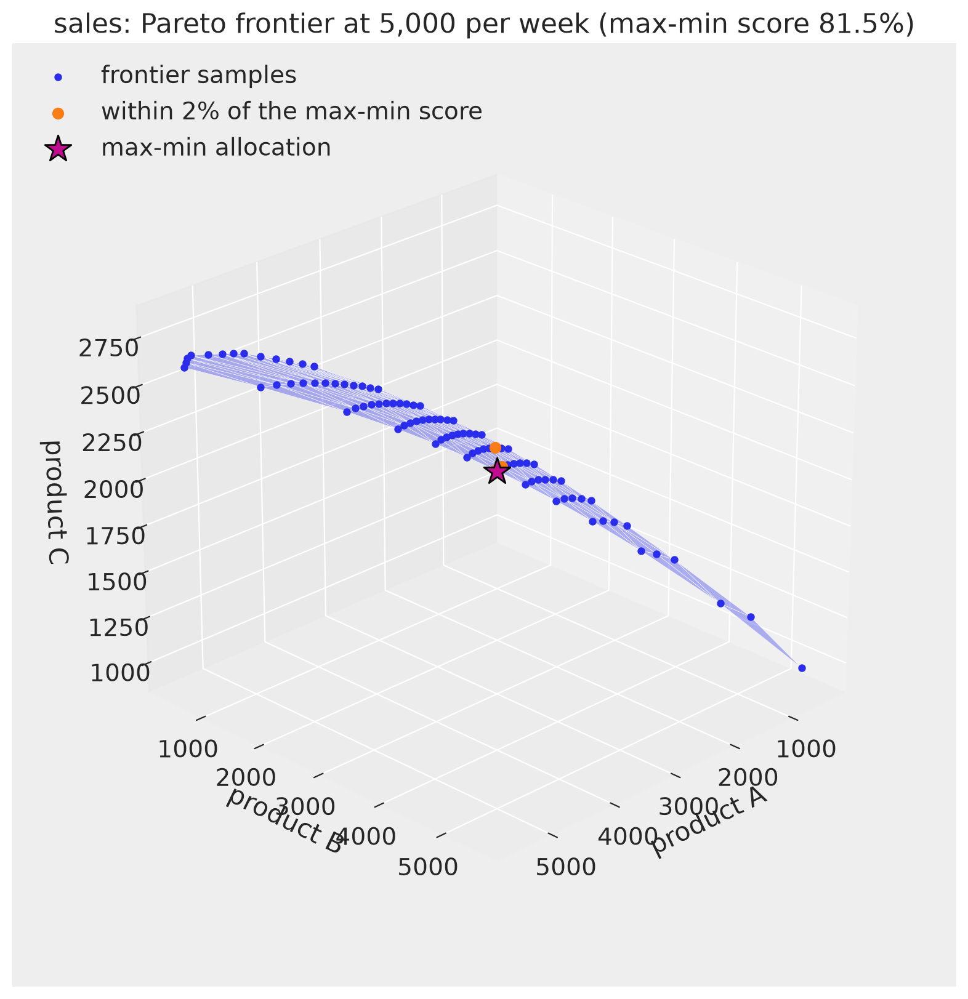

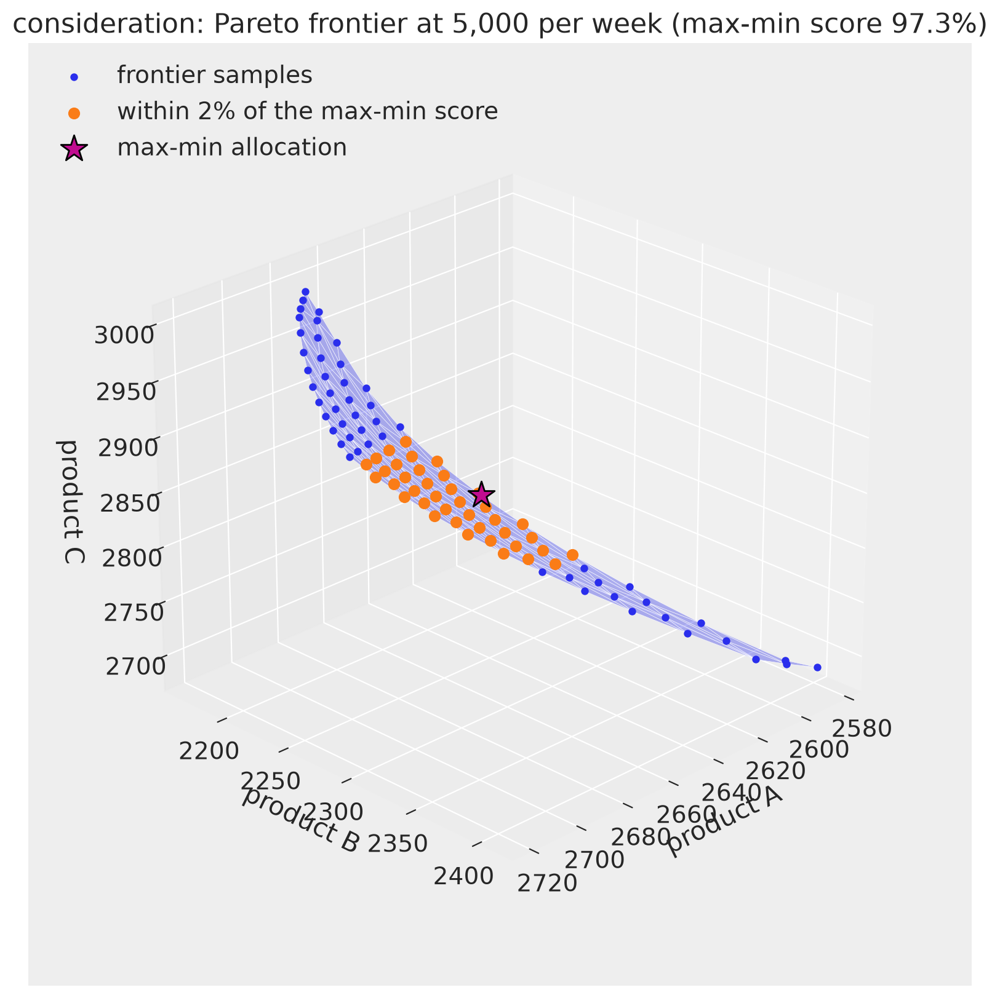

In [11]:
for target in frontier_targets:
    frontier = product_frontiers[target]
    response = frontier["responses"]
    near_balance = (response / frontier["ideal_response"]).min(
        axis=1
    ) >= 0.98 * frontier["balance_score"]

    fig = plt.figure(figsize=(11, 8), layout="constrained")
    ax = fig.add_subplot(projection="3d", computed_zorder=False)
    ax.plot_trisurf(
        response[:, 0],
        response[:, 1],
        response[:, 2],
        triangles=frontier_triangles,
        color="C0",
        edgecolor="white",
        linewidth=0.2,
        alpha=0.35,
        shade=False,
        zorder=1,
    )
    ax.scatter(
        *response.T,
        color="C0",
        s=12,
        depthshade=False,
        label="frontier samples",
        zorder=2,
    )
    ax.scatter(
        *response[near_balance].T,
        color="C1",
        s=35,
        depthshade=False,
        label="within 2% of the max-min score",
        zorder=3,
    )
    ax.scatter(
        *frontier["balanced_response"],
        color="C3",
        marker="*",
        s=260,
        edgecolor="black",
        depthshade=False,
        label="max-min allocation",
        zorder=4,
    )
    ax.set(
        title=(
            f"{target}: Pareto frontier at {weekly_budget:,.0f} per week "
            f"(max-min score {frontier['balance_score']:.1%})"
        ),
        xlabel=products[0],
        ylabel=products[1],
        zlabel=products[2],
    )
    ax.zaxis.labelpad = 15
    ax.set_box_aspect((1, 1, 0.85), zoom=0.85)
    ax.view_init(elev=25, azim=45)
    ax.legend(loc="upper left")

The two surfaces have different shapes because the channel preferences conflict more for sales than for consideration, where all products like `search` and `display`. The tables show what the max-min allocation spends and what each product gets, in weekly units.

In [12]:
balanced_product_summary = pd.DataFrame(
    {
        target: frontier["balanced_response"]
        for target, frontier in product_frontiers.items()
    },
    index=pd.Index(products, name="product"),
)
balanced_budget_summary = pd.DataFrame(
    {
        target: frontier["balanced_allocation"]
        for target, frontier in product_frontiers.items()
    },
    index=pd.Index(channels, name="channel"),
)
display(balanced_budget_summary.round(0))
display(balanced_product_summary.round(0))
for target, frontier in product_frontiers.items():
    print(f"{target}: max-min score {frontier['balance_score']:.1%}")

,sales,consideration
channel,,
out of home,1262.0,245.0
TV,990.0,322.0
social media,496.0,879.0
search,990.0,1991.0
display,1262.0,1563.0


,sales,consideration
product,,
product A,4472.0,2695.0
product B,4472.0,2343.0
product C,2458.0,2914.0


sales: max-min score 81.5%
consideration: max-min score 97.3%


For sales, the max-min plan is symmetric between the two products' channels: $1{,}262$ per week on `out of home` and on `display`, $990$ on `TV` and on `search`, and the rest on `social media`. Products A and B both get $4{,}472$ in weekly sales, which is $81.5\%$ of what each could get with the whole budget to itself. Product C gets less in absolute terms because its response curves are smaller, but the max-min rule compares each product with its own best, not with the others. For consideration, the plan concentrates on `search` and `display` and the score is $97.3\%$: all three products want the same channels, so there is little to trade.

## Fit the Model

Now we forget the true parameters and fit `base_model` to the $100$ weeks of simulated outcomes. We sample four chains with `nutpie` and keep only the stochastic parameters in the trace; the deterministic contributions are large and we recompute them below when needed.

In [13]:
parameter_names = [
    "adstock_alpha",
    "saturation_alpha",
    "saturation_lam",
    "intercept",
    "sigma",
]
with base_model:
    idata = pm.sample(
        draws=2_000,
        tune=1_500,
        chains=4,
        cores=4,
        nuts_sampler="nutpie",
        target_accept=0.95,
        random_seed=seed,
        var_names=parameter_names,
    )

NUTS[nutpie]: [adstock_alpha, saturation_alpha, saturation_lam, intercept, sigma]


Output()

### Diagnostics

We check for divergences, $\hat{R}$ below $1.01$, and bulk and tail effective sample sizes of at least $400$ for every one of the $153$ parameters. The full summary is long, so we print the overview and only list the parameters that fail a check.

In [14]:
posterior_summary = az.summary(idata, var_names=parameter_names, round_to=4)
divergences = int(idata.sample_stats["diverging"].sum().item())
convergence_overview = pd.Series(
    {
        "divergences": divergences,
        "max r_hat": posterior_summary["r_hat"].max(),
        "min ess_bulk": posterior_summary["ess_bulk"].min(),
        "min ess_tail": posterior_summary["ess_tail"].min(),
    },
    name="base model",
)
display(convergence_overview.round(3))

diagnostic_columns = ["r_hat", "ess_bulk", "ess_tail"]
flagged_parameters = posterior_summary.loc[
    (posterior_summary["r_hat"] >= 1.01)
    | (posterior_summary["ess_bulk"] < 400)
    | (posterior_summary["ess_tail"] < 400)
    | posterior_summary[diagnostic_columns].isna().any(axis=1)
]
print(f"Flagged parameters: {len(flagged_parameters)}")
flagged_parameters

divergences        0.000
max r_hat          1.004
min ess_bulk    1717.390
min ess_tail    1483.527
Name: base model, dtype: float64

Flagged parameters: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd


No divergences, the largest $\hat{R}$ is $1.004$, and the smallest effective sample sizes are above $1{,}400$. The trace plot below shows one slice, product A's `TV` response for `sales`; change `diagnostic_coords` to look at others.

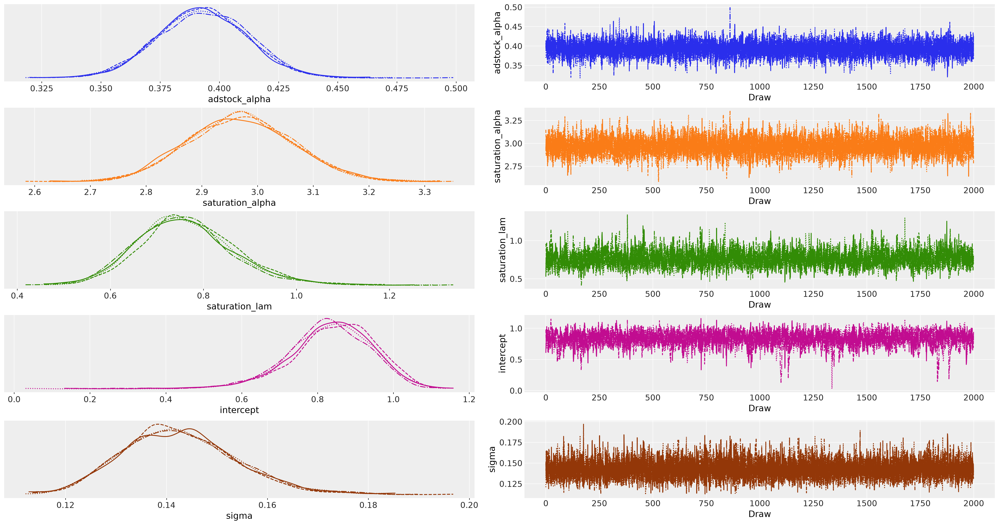

In [15]:
diagnostic_coords = {
    "product": ["product A"],
    "channel": ["TV"],
    "target": ["sales"],
}
azp.plot_trace_dist(
    idata,
    var_names=parameter_names,
    coords=diagnostic_coords,
    backend="matplotlib",
);

### Parameter recovery

The real check is whether the model recovers the channel contributions it was generated from. We draw the contributions and the outcomes from the posterior at the historical spend and compare them with the true values. The bands are pointwise $94\%$ HDIs: for contributions they reflect parameter uncertainty only, for outcomes they also include the observation noise.

Sampling: [y]


Output()

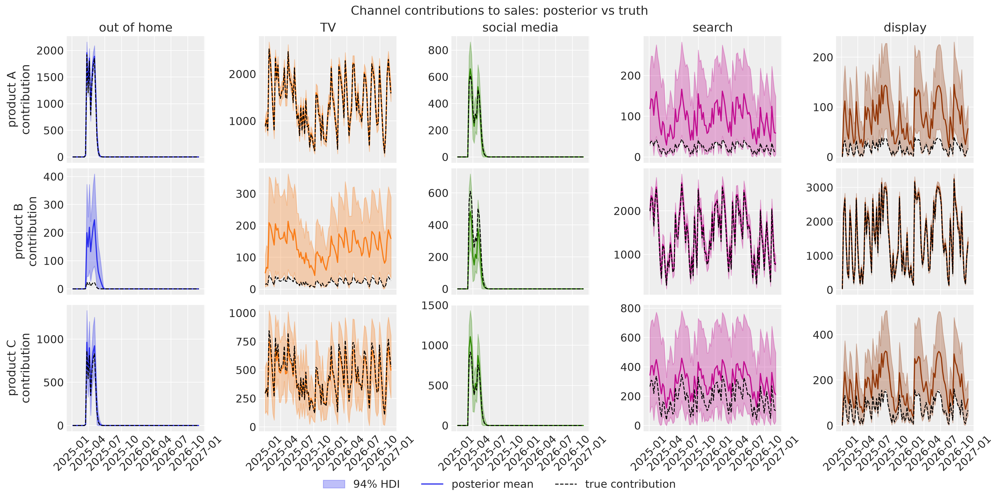

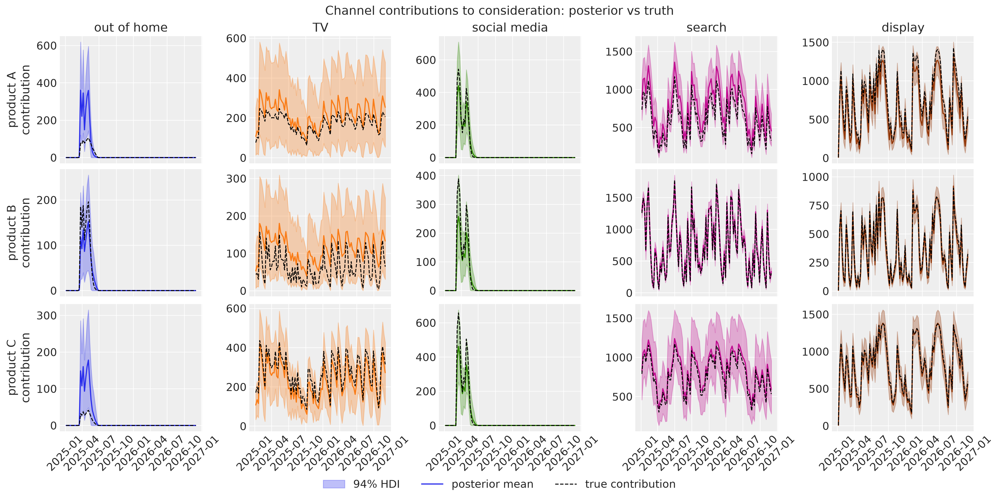

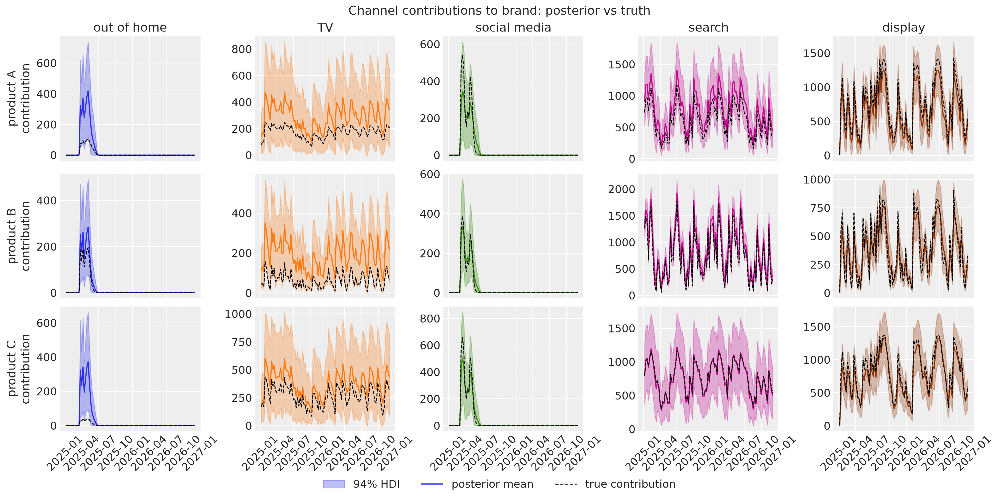

In [16]:
with base_model:
    posterior_predictive = pm.sample_posterior_predictive(
        idata, var_names=["contribution", "y"], random_seed=seed
    )

recovery_samples = posterior_predictive.posterior_predictive.to_dataset()
recovery_mean = recovery_samples.mean(dim=("chain", "draw"))
recovery_hdi = az.hdi(recovery_samples, prob=HDI_PROB)


def plot_recovery_band(ax, x, hdi: xr.DataArray, color: str, label: str) -> None:
    """Fill the HDI band of one series."""
    ax.fill_between(
        x,
        hdi.sel(ci_bound="lower").values,
        hdi.sel(ci_bound="upper").values,
        color=color,
        alpha=0.3,
        label=label,
    )


for target in targets:
    fig, axes = plt.subplots(
        nrows=len(products),
        ncols=len(channels),
        figsize=(18, 9),
        sharex=True,
        layout="constrained",
    )
    for row, product in enumerate(products):
        for col, channel in enumerate(channels):
            ax = axes[row, col]
            selection = {"product": product, "channel": channel, "target": target}
            plot_recovery_band(
                ax,
                dates,
                recovery_hdi["contribution"].sel(selection),
                color=f"C{col}",
                label=f"{HDI_PROB:.0%} HDI",
            )
            ax.plot(
                dates,
                recovery_mean["contribution"].sel(selection),
                color=f"C{col}",
                label="posterior mean",
            )
            ax.plot(
                dates,
                true_contribution.sel(selection),
                color="black",
                linestyle="--",
                linewidth=1.2,
                label="true contribution",
            )
            if row == 0:
                ax.set_title(channel)
            if col == 0:
                ax.set_ylabel(f"{product}\ncontribution")
            ax.tick_params(axis="x", labelrotation=45)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncol=3)
    fig.suptitle(f"Channel contributions to {target}: posterior vs truth", fontsize=16)

The true contributions sit inside the bands everywhere, and the channels that matter are recovered tightly: `TV` for product A, `search` and `display` for product B. The bands are widest where the data carry the least information: `out of home` and `social media` only ran for ten weeks, and for channels with almost no true effect (`search` and `display` for product A, `TV` for product B) the posterior can only say that the contribution is small.

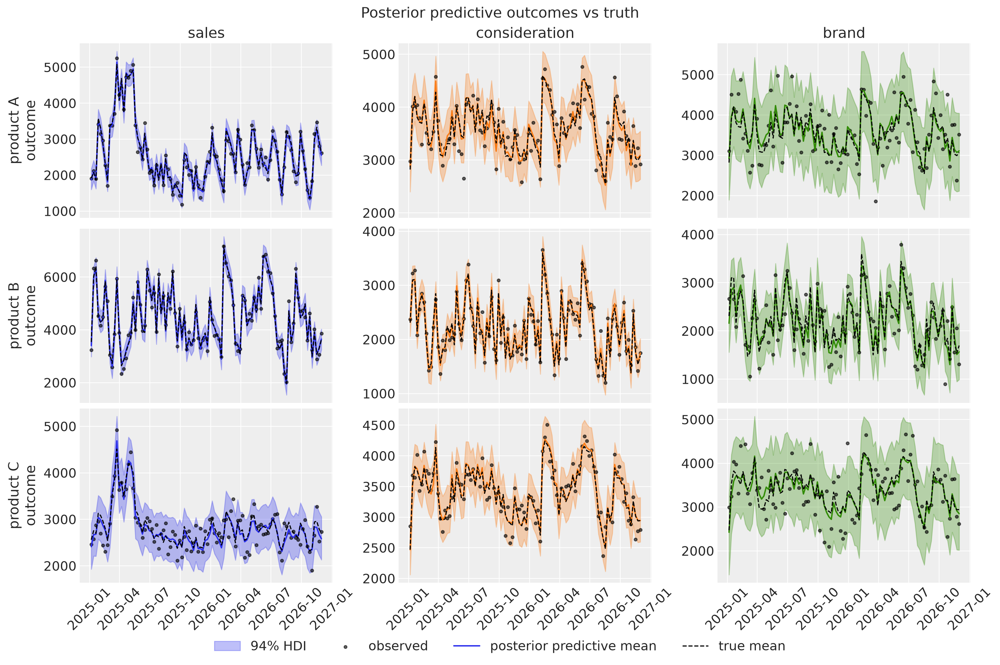

In [17]:
fig, axes = plt.subplots(
    nrows=len(products),
    ncols=len(targets),
    figsize=(15, 10),
    sharex=True,
    layout="constrained",
)
for row, product in enumerate(products):
    for col, target in enumerate(targets):
        ax = axes[row, col]
        selection = {"product": product, "target": target}
        plot_recovery_band(
            ax,
            dates,
            recovery_hdi["y"].sel(selection),
            color=f"C{col}",
            label=f"{HDI_PROB:.0%} HDI",
        )
        ax.scatter(
            dates,
            target_values.sel(selection),
            color="black",
            s=10,
            alpha=0.6,
            label="observed",
        )
        ax.plot(
            dates,
            recovery_mean["y"].sel(selection),
            color=f"C{col}",
            label="posterior predictive mean",
        )
        ax.plot(
            dates,
            true_mu.sel(selection),
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="true mean",
        )
        if row == 0:
            ax.set_title(target)
        if col == 0:
            ax.set_ylabel(f"{product}\noutcome")
        ax.tick_params(axis="x", labelrotation=45)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=4)
fig.suptitle("Posterior predictive outcomes vs truth", fontsize=16);

The posterior predictive means follow the true means closely for all nine series; the wider bands in the `brand` column are the doubled observation noise, as designed.

## Five Priorities, One Weekly Budget

We now put the fitted posterior to work. Every plan below spends the same $5{,}000$ per week across the five channels. What differs is the business priority:

| Policy | Maximizes | Products |
|---|---|---|
| Product B sales | expected media-driven sales | product B only |
| Product A sales | expected media-driven sales | product A only |
| Total consideration | expected media-driven consideration, summed over products | all three |
| Total brand | expected media-driven brand, summed over products | all three |
| Balanced sales | the smallest fraction of each product's own best sales (max-min) | all three |

These are five different questions, not five estimates of the same thing. The point of the exercise is to see how much each priority costs the others.

### A steady-state horizon

We follow the custom-utility interface of {class}`~pymc_marketing.mmm.budget_optimizer.BudgetOptimizer`: clone the fitted model, resize its data containers to the planning horizon, and pass the posterior `idata`. The optimizer holds each channel budget constant over the horizon. With $7$ normalized adstock lags, $7$ weeks of constant spend put the last week exactly at steady state, so we optimize the contribution in the final week. The budget is per week; the optimizer sees a $7$-week window, but nothing depends on its length once steady state is reached.

In [18]:
optimization_horizon = adstock.l_max
optimization_dates = pd.date_range(
    dates[-1] + pd.Timedelta(weeks=1), periods=optimization_horizon, freq="W-MON"
)


def optimization_clone(model: pm.Model) -> pm.Model:
    """Clone a fitted model and resize its data containers to the planning horizon."""
    clone = clone_model(model)
    with clone:
        pm.set_data(
            {
                "channel_data": np.zeros((optimization_horizon, len(channels))),
                "target_data": np.zeros(
                    (optimization_horizon, len(products), len(targets))
                ),
            },
            coords={"date": optimization_dates},
        )
    return clone


optimization_model = optimization_clone(base_model)
product_index = {product: i for i, product in enumerate(products)}
target_index = {target: i for i, target in enumerate(targets)}

### Utilities

A utility receives the symbolic response `samples`, with a `sample` dimension for the posterior draws in front of the model's own dimensions, and the symbolic `budgets`. It returns the scalar to maximize. Symbolic tensors know dimension names but not coordinate labels, so we select products and outcomes by position.

We solve each problem from six starting points (equal spend and each channel corner) and keep the best feasible solution. The objectives are concave in the budget, so all starts should agree; the table of solver runs is a cheap check that they do.

In [19]:
def expected_sales(samples: XTensorVariable) -> XTensorVariable:
    """Return posterior-mean media-driven sales in the final week, per product."""
    return (
        samples.isel(date=-1, target=target_index["sales"])
        .sum(dim="channel")
        .mean(dim="sample")
    )


def maximize_product_b_sales(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return product B's expected sales."""
    return expected_sales(samples).isel(product=product_index["product B"])


def maximize_product_a_sales(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return product A's expected sales."""
    return expected_sales(samples).isel(product=product_index["product A"])


def maximize_product_c_sales(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return product C's expected sales (only the third ideal for the balanced policy)."""
    return expected_sales(samples).isel(product=product_index["product C"])


def maximize_total_consideration(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return expected consideration summed over all products."""
    return (
        samples.isel(date=-1, target=target_index["consideration"])
        .sum(dim=("product", "channel"))
        .mean(dim="sample")
    )


def maximize_total_brand(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return expected brand summed over all products."""
    return (
        samples.isel(date=-1, target=target_index["brand"])
        .sum(dim=("product", "channel"))
        .mean(dim="sample")
    )


starting_allocations = np.vstack(
    [
        np.full(len(channels), weekly_budget / len(channels)),
        weekly_budget * np.eye(len(channels)),
    ]
)
start_names = ["equal spend", *[f"all {channel}" for channel in channels]]
# SLSQP's absolute tolerance has to match the scale of the response.
minimize_kwargs = {
    "method": "SLSQP",
    "options": {"ftol": 1e-9 * unit_scale, "maxiter": 2_000},
}
budget_tolerance = 1e-6


def budget_is_feasible(allocation: np.ndarray, total_budget: float) -> bool:
    """Check that an allocation is non-negative, within bounds, and sums to the budget."""
    return bool(
        np.isfinite(allocation).all()
        and (allocation >= -budget_tolerance).all()
        and (allocation <= total_budget + budget_tolerance).all()
        and abs(allocation.sum() - total_budget) <= budget_tolerance
    )


def maximize_utility(
    model: pm.Model,
    posterior: xr.DataTree,
    response_variable: str,
    utility_function: Callable[[XTensorVariable, XTensorVariable], XTensorVariable],
) -> tuple[BudgetOptimizationResult, pd.DataFrame]:
    """Run the optimizer from every start and keep the best feasible solution."""
    optimizer = BudgetOptimizer(
        model=model,
        idata=posterior,
        num_periods=optimization_horizon,
        response_variable=response_variable,
        utility_function=utility_function,
    )
    runs = [
        optimizer.allocate_budget(
            total_budget=weekly_budget,
            budget_bounds={channel: (0.0, weekly_budget) for channel in channels},
            x0=start,
            minimize_kwargs=minimize_kwargs,
            return_if_fail=True,
        )
        for start in starting_allocations
    ]
    records = pd.DataFrame(
        {
            "start": start_names,
            "success": [run.scipy_result.success for run in runs],
            "feasible": [
                budget_is_feasible(run.budgets.values, weekly_budget) for run in runs
            ],
            "utility": [-run.scipy_result.fun for run in runs],
        }
    ).set_index("start")
    accepted = [
        run
        for run, ok in zip(runs, records["success"] & records["feasible"], strict=True)
        if ok
    ]
    if not accepted:
        raise RuntimeError(f"No start converged for {utility_function.__name__}.")
    return min(accepted, key=lambda run: run.scipy_result.fun), records


priority_utilities = {
    "Product B sales": maximize_product_b_sales,
    "Product A sales": maximize_product_a_sales,
    "Total consideration": maximize_total_consideration,
    "Total brand": maximize_total_brand,
}
priority_results = {}
priority_runs = {}
for policy, utility_function in priority_utilities.items():
    priority_results[policy], priority_runs[policy] = maximize_utility(
        optimization_model, idata, "contribution", utility_function
    )
pd.concat(priority_runs, names=["policy"])["utility"].unstack("start").round(1)

start,equal spend,all out of home,all TV,all social media,all search,all display
policy,,,,,,
Product B sales,5507.6,5507.6,5507.6,5507.6,5507.6,5507.6
Product A sales,5250.0,5250.0,5250.0,5250.0,5250.0,5250.0
Total consideration,8144.5,8144.5,8144.5,8144.5,8144.5,8144.5
Total brand,8859.3,8859.3,8859.3,8859.3,8859.3,8859.3


### The balanced policy

The max-min rule needs each product's ideal $I_p$, its best expected sales when the whole budget serves it alone. Product A's and product B's ideals are the two single-product policies above; product C's comes from one more optimization that we do not show as a policy.

We then reuse `balanced_product_allocation` with the full stack of posterior draws for the sales parameters. Both `saturation_alpha` and `saturation_lam` are stored in model units, so both are multiplied by `unit_scale` before they meet the raw budgets. The response is evaluated in every draw and averaged, so the criterion is the smallest *posterior-mean* attainment; it is not a probability guarantee. As a consistency check, the closed-form steady-state response at the single-product optima must match the optimizer's own objective values.

In [20]:
posterior_maximum = unit_scale * idata.posterior["saturation_alpha"]
posterior_half_saturation = unit_scale * idata.posterior["saturation_lam"]


def stacked_sales_parameters(posterior: xr.Dataset) -> tuple[np.ndarray, np.ndarray]:
    """Stack the sales saturation parameters as ``(sample, product, channel)`` arrays in raw units."""
    maximum = (
        (unit_scale * posterior["saturation_alpha"])
        .sel(target="sales", drop=True)
        .stack(sample=("chain", "draw"))
        .transpose("sample", "product", "channel")
        .values
    )
    half_saturation = (
        (unit_scale * posterior["saturation_lam"])
        .sel(target="sales", drop=True)
        .stack(sample=("chain", "draw"))
        .transpose("sample", "product", "channel")
        .values
    )
    return maximum, half_saturation


sales_maximum, sales_half_saturation = stacked_sales_parameters(idata.posterior)

product_c_result, _ = maximize_utility(
    optimization_model, idata, "contribution", maximize_product_c_sales
)
single_product_results = {
    "product A": priority_results["Product A sales"],
    "product B": priority_results["Product B sales"],
    "product C": product_c_result,
}
sales_ideals = xr.DataArray(
    [
        product_response_and_gradient(
            single_product_results[product].budgets.sel(channel=channels).values,
            sales_maximum,
            sales_half_saturation,
        )[0][product_index[product]]
        for product in products
    ],
    dims="product",
    coords={"product": products},
    name="ideal sales",
)
for product, result in single_product_results.items():
    np.testing.assert_allclose(
        sales_ideals.sel(product=product), -result.scipy_result.fun, rtol=1e-6
    )

balance_candidates = []
for start in starting_allocations:
    allocation, score = balanced_product_allocation(
        sales_maximum, sales_half_saturation, sales_ideals.values, start, weekly_budget
    )
    if budget_is_feasible(allocation, weekly_budget):
        balance_candidates.append((allocation, score))
balanced_budget, balance_score = max(balance_candidates, key=lambda c: c[1])

priority_names = [*priority_utilities, "Balanced sales"]
priority_allocations = (
    xr.concat(
        [
            priority_results[policy].budgets.sel(channel=channels)
            for policy in priority_utilities
        ]
        + [xr.DataArray(balanced_budget, dims="channel", coords={"channel": channels})],
        dim="policy",
    )
    .assign_coords(policy=priority_names)
    .transpose("policy", "channel")
)
weekly_allocation = priority_allocations.sel(policy="Balanced sales", drop=True)

display(sales_ideals.to_series().to_frame().round(0))
print(
    f"Balanced sales: the worst-off product reaches {balance_score:.1%} of its own best sales."
)

,ideal sales
product,
product A,5250.0
product B,5508.0
product C,3234.0


Balanced sales: the worst-off product reaches 88.1% of its own best sales.


### What each policy spends and what it buys

We evaluate all five allocations with the closed-form steady-state response, draw by draw, so that every policy is scored on the same posterior. The first table is the allocation, the second scores every policy on all five objectives. Each policy is best in its own column by construction; the interesting part is the other columns.

In [21]:
priority_media_draws = (
    (
        posterior_maximum
        * priority_allocations
        / (posterior_half_saturation + priority_allocations)
    )
    .sum("channel")
    .transpose("policy", "chain", "draw", "product", "target")
)
priority_media_mean = priority_media_draws.mean(("chain", "draw"))
priority_media_hdi = az.hdi(
    priority_media_draws.to_dataset(name="response"), prob=HDI_PROB
)["response"]
priority_attainment = priority_media_mean.sel(target="sales", drop=True) / sales_ideals

priority_allocation_table = priority_allocations.to_pandas()
priority_allocation_table["total"] = priority_allocations.sum("channel").values
display(priority_allocation_table.round(0))

priority_score_table = (
    xr.Dataset(
        {
            "Product B sales": priority_media_mean.sel(
                product="product B", target="sales", drop=True
            ),
            "Product A sales": priority_media_mean.sel(
                product="product A", target="sales", drop=True
            ),
            "Product C sales": priority_media_mean.sel(
                product="product C", target="sales", drop=True
            ),
            "Total consideration": priority_media_mean.sel(
                target="consideration", drop=True
            ).sum("product"),
            "Total brand": priority_media_mean.sel(target="brand", drop=True).sum(
                "product"
            ),
            "Min sales attainment (%)": 100 * priority_attainment.min("product"),
        }
    )
    .to_dataframe()
    .reindex(priority_names)
)
display(priority_score_table.round(0))

# The closed form must agree with the optimizer's objective for each single-objective policy.
for policy, result in priority_results.items():
    np.testing.assert_allclose(
        priority_score_table.loc[policy, policy], -result.scipy_result.fun, rtol=1e-6
    )
np.testing.assert_allclose(
    priority_attainment.sel(policy="Balanced sales").min(), balance_score, rtol=1e-6
)

channel,out of home,TV,social media,search,display,total
policy,,,,,,
Product B sales,424.0,39.0,371.0,1903.0,2262.0,5000.0
Product A sales,2041.0,2108.0,817.0,33.0,0.0,5000.0
Total consideration,683.0,341.0,542.0,1750.0,1684.0,5000.0
Total brand,922.0,485.0,443.0,1625.0,1525.0,5000.0
Balanced sales,1260.0,1134.0,437.0,963.0,1206.0,5000.0


,Product B sales,Product A sales,Product C sales,Total consideration,Total brand,Min sales attainment (%)
policy,,,,,,
Product B sales,5508.0,2173.0,1871.0,7947.0,8364.0,41.0
Product A sales,1075.0,5250.0,2894.0,3018.0,4215.0,20.0
Total consideration,5411.0,3390.0,2438.0,8144.0,8804.0,65.0
Total brand,5322.0,3815.0,2586.0,8102.0,8859.0,73.0
Balanced sales,4850.0,4624.0,2850.0,7564.0,8449.0,88.0


The single-product policies are corner solutions. Maximizing product A's sales puts $2{,}041$ on `out of home` and $2{,}108$ on `TV`, nothing on `display`, and leaves product B at $20\%$ of its own best; maximizing product B's sales does the mirror image and leaves product A at $41\%$. The two total policies land close to each other: `Total consideration` and `Total brand` differ by less than $1\%$ on both totals ($8{,}144$ versus $8{,}102$ consideration, $8{,}804$ versus $8{,}859$ brand), even though the brand allocation puts about $380$ more on `out of home` and `TV`. Remember that both outcomes have the same true response; the difference between the two plans is estimation noise, and it is not large. The balanced policy costs each product about $12\%$ of its own best sales ($4{,}850$ instead of $5{,}508$ for product B, $4{,}624$ instead of $5{,}250$ for product A) and in exchange lifts every product, including product C, to $88\%$ of its potential. It also gives up $7\%$ of the best total consideration.

The left panel shows where each policy puts the money; the right panel shows each product's expected weekly sales with $94\%$ HDIs.

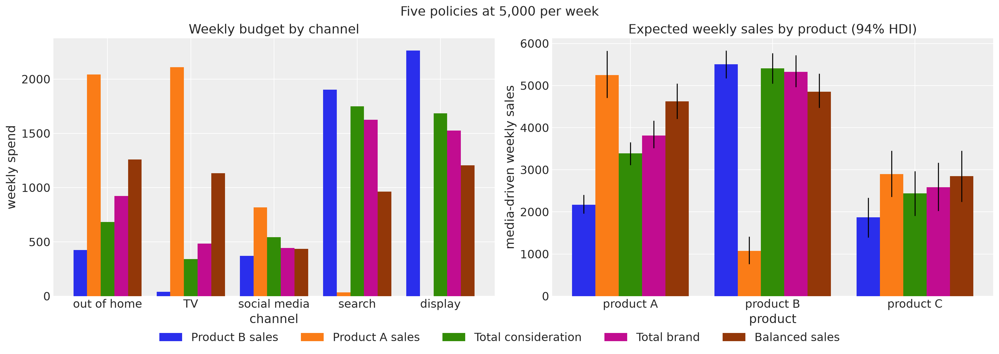

In [22]:
priority_colors = {policy: f"C{i}" for i, policy in enumerate(priority_names)}
bar_width = 0.82 / len(priority_names)
channel_positions = np.arange(len(channels))
product_positions = np.arange(len(products))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(17, 6), layout="constrained")
for policy_index, policy in enumerate(priority_names):
    offset = (policy_index - (len(priority_names) - 1) / 2) * bar_width
    axes[0].bar(
        channel_positions + offset,
        priority_allocations.sel(policy=policy),
        width=bar_width,
        color=priority_colors[policy],
        label=policy,
    )
    sales_mean = priority_media_mean.sel(policy=policy, target="sales")
    sales_hdi = priority_media_hdi.sel(policy=policy, target="sales")
    positions = product_positions + offset
    axes[1].bar(positions, sales_mean, width=bar_width, color=priority_colors[policy])
    axes[1].vlines(
        positions,
        sales_hdi.sel(ci_bound="lower"),
        sales_hdi.sel(ci_bound="upper"),
        color="black",
        linewidth=1.2,
    )
axes[0].set(
    title="Weekly budget by channel",
    xlabel="channel",
    ylabel="weekly spend",
    xticks=channel_positions,
    xticklabels=channels,
)
axes[1].set(
    title=f"Expected weekly sales by product ({HDI_PROB:.0%} HDI)",
    xlabel="product",
    ylabel="media-driven weekly sales",
    xticks=product_positions,
    xticklabels=products,
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=5)
fig.suptitle(f"Five policies at {weekly_budget:,.0f} per week", fontsize=16);

The violins show the full posterior of the steady-state response under each policy: sales by product on the first row, and total consideration and total brand on the second. The dot is the posterior mean and the line the $94\%$ HDI. Uncertainty comes from the parameters, not from the allocation, which is fixed.

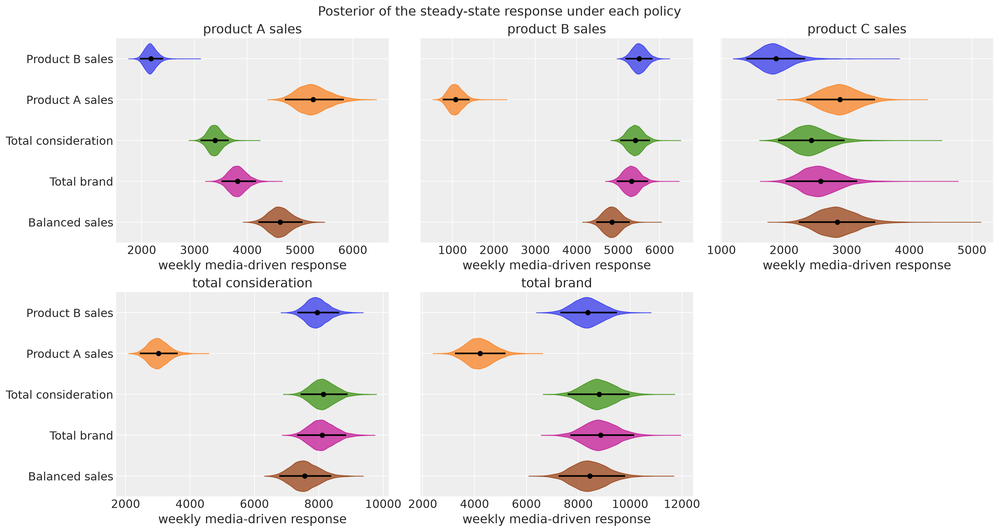

In [23]:
violin_panels = [
    (
        f"{product} sales",
        priority_media_draws.sel(product=product, target="sales", drop=True),
    )
    for product in products
] + [
    (
        f"total {target}",
        priority_media_draws.sel(target=target, drop=True).sum("product"),
    )
    for target in ["consideration", "brand"]
]
policy_positions = np.arange(len(priority_names))
fig, axes = plt.subplots(
    nrows=2, ncols=3, figsize=(17, 9), sharey=True, layout="constrained"
)
axes = axes.ravel()
axes[-1].axis("off")
for ax, (title, draws) in zip(axes, violin_panels, strict=False):
    policy_draws = [
        draws.sel(policy=policy).values.ravel() for policy in priority_names
    ]
    violins = ax.violinplot(
        policy_draws,
        positions=policy_positions,
        orientation="horizontal",
        widths=0.75,
        showextrema=False,
    )
    for body, policy in zip(violins["bodies"], priority_names, strict=True):
        body.set_facecolor(priority_colors[policy])
        body.set_edgecolor(priority_colors[policy])
        body.set_alpha(0.7)
    hdi = az.hdi(draws.to_dataset(name="response"), prob=HDI_PROB)["response"]
    ax.hlines(
        policy_positions,
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color="black",
        linewidth=2,
    )
    ax.scatter(
        draws.mean(("chain", "draw")),
        policy_positions,
        color="black",
        s=30,
        zorder=3,
    )
    ax.set(
        title=title,
        xlabel="weekly media-driven response",
        yticks=policy_positions,
        yticklabels=priority_names,
        ylim=(len(priority_names) - 0.5, -0.5),
    )
fig.suptitle("Posterior of the steady-state response under each policy", fontsize=16);

The violins tell the same story with uncertainty attached. The sales posteriors of the single-product policies do not overlap with the balanced policy for the product they neglect; for product B the `Product A sales` plan sits around $1{,}000$ against $4{,}850$. In the bottom row, the `Total consideration` and `Total brand` posteriors are on top of each other, and the balanced plan is only slightly below them on both totals. The wide product C violins reflect that its sales parameters are the least well identified: its channel effects are moderate everywhere and large nowhere.

We keep the balanced allocation as `weekly_allocation`. It is the plan we would take to the next step if the model stopped here. The next two sections change the model, and then the question.

## Spillover Between Products

So far each product's outcomes depend only on its own response to the shared spend. A common complication is spillover: media that is meant for one product also lifts another. Here we let product A's `consideration` contribution from `out of home` and `social media` spill into product B's `consideration`.

We use the masked, bounded-share construction from {ref}`mmm_halo`. Each active route $(s, k, c)$ gets a learned share $\rho_{s,k,c}$ of the source product's direct contribution, and a Boolean mask $M$ fixes which routes exist:

$$
\rho_{s,k,c} = 0.5\,u_{s,k,c}, \qquad u_{s,k,c} \sim \operatorname{Beta}(8, 2),
\qquad
S_{t,p,k} = \sum_{s,c} M_{p,s,k,c}\,\rho_{s,k,c}\,f_{t,s,k,c},
\qquad
\mu_{t,p,k} = a_{p,k} + \sum_c f_{t,p,k,c} + S_{t,p,k}.
$$

{class}`~pymc_marketing.special_priors.MaskedPrior` samples only the two active shares and expands them to exact zeros at the other $43$ positions. The spillover is additive: product A keeps its full direct contribution, and product B inherits product A's adstock and saturation for the routed part.

```{warning}
The data were generated without spillover, and with *shared* spend the likelihood can barely tell product B's own `out of home` response from spillover of product A's. The prior does most of the work here: $\operatorname{Beta}(8, 2)$ with a $0.5$ cap has mean share $0.40$, which is deliberately strong. Read this section as "what changes in the plan if we believe in spillover of this size", not as an estimate of spillover. {ref}`mmm_halo` discusses when such effects are identified.
```

The builder below adds the effect to a fresh base model and swaps in the extended mean with `pm.do`. The same code could be packaged as a `MuEffect` for the `MMM` class, as in {ref}`mmm_halo`; here we keep it as a function.

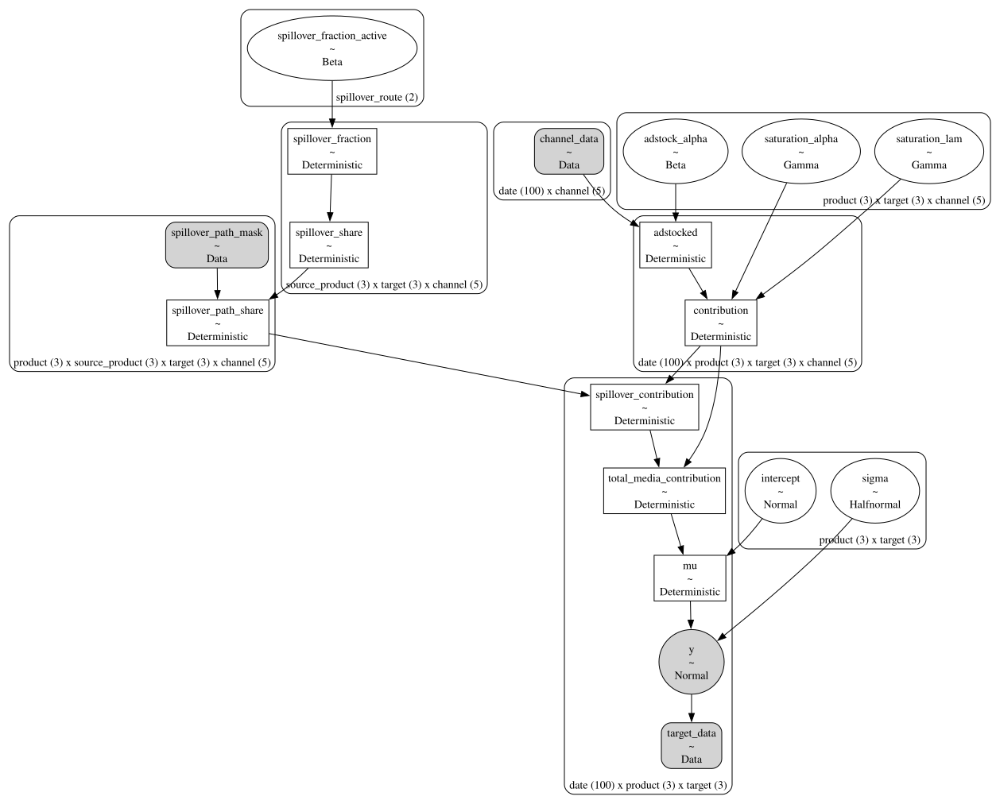

In [24]:
spill_source_dims = ("source_product", "target", "channel")
spill_path_dims = ("product", *spill_source_dims)
spill_mask = xr.DataArray(
    np.zeros((len(products), len(products), len(targets), len(channels)), dtype=bool),
    dims=spill_path_dims,
    coords={
        "product": products,
        "source_product": products,
        "target": targets,
        "channel": channels,
    },
)
spill_mask.loc[
    {
        "product": "product B",
        "source_product": "product A",
        "target": "consideration",
        "channel": ["out of home", "social media"],
    }
] = True
spill_max_share = 0.5
spill_fraction_prior = Prior("Beta", alpha=8, beta=2, dims=spill_source_dims)


def build_spillover_model() -> pm.Model:
    """Build the base model plus a learned share of product A's media routed into product B."""
    model = build_base_model()
    with model:
        model.add_coord("source_product", values=products)
        path_mask = pmd.Data("spillover_path_mask", spill_mask.astype(float))
        fraction = MaskedPrior(
            spill_fraction_prior,
            mask=spill_mask.any("product"),
            active_dim="spillover_route",
        ).create_variable("spillover_fraction", xdist=True)
        share = pmd.Deterministic(
            "spillover_share",
            (spill_max_share * fraction).transpose(*spill_source_dims),
        )
        path_share = pmd.Deterministic(
            "spillover_path_share", (share * path_mask).transpose(*spill_path_dims)
        )
        source_contribution = model["contribution"].rename(
            {"product": "source_product"}
        )
        spillover_contribution = pmd.Deterministic(
            "spillover_contribution",
            (path_share * source_contribution)
            .sum(dim=("source_product", "channel"))
            .transpose("date", "product", "target"),
        )
        total_media_contribution = pmd.Deterministic(
            "total_media_contribution",
            model["contribution"].sum(dim="channel") + spillover_contribution,
            dims=("date", "product", "target"),
        )
        extended_mu = (
            unit_scale * model["intercept"] + total_media_contribution
        ).transpose("date", "product", "target")
    return pm.do(model, {"mu": extended_mu})


spillover_model = build_spillover_model()
pm.model_to_graphviz(spillover_model)

`contribution` still holds the direct channel contributions; `spillover_contribution` is the routed part, and `total_media_contribution` is their sum without the intercept. The optimization later uses this total.

We fit the extended model on the same observations. Everything is re-estimated jointly, so the direct parameters can shift as well.

In [25]:
spillover_parameter_names = [*parameter_names, "spillover_fraction_active"]
with spillover_model:
    spillover_idata = pm.sample(
        draws=2_000,
        tune=1_500,
        chains=4,
        cores=4,
        nuts_sampler="nutpie",
        target_accept=0.95,
        random_seed=seed,
        var_names=[
            *spillover_parameter_names,
            "spillover_share",
            "spillover_path_share",
            "spillover_contribution",
        ],
    )

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, spillover_fraction_active, intercept, sigma]


Output()

In [26]:
spillover_summary = az.summary(
    spillover_idata, var_names=spillover_parameter_names, round_to=4
)
spillover_convergence = pd.Series(
    {
        "divergences": int(spillover_idata.sample_stats["diverging"].sum().item()),
        "max r_hat": spillover_summary["r_hat"].max(),
        "min ess_bulk": spillover_summary["ess_bulk"].min(),
        "min ess_tail": spillover_summary["ess_tail"].min(),
    },
    name="spillover model",
)
display(spillover_convergence.round(3))
spillover_flagged = spillover_summary.loc[
    (spillover_summary["r_hat"] >= 1.01)
    | (spillover_summary["ess_bulk"] < 400)
    | (spillover_summary["ess_tail"] < 400)
    | spillover_summary[diagnostic_columns].isna().any(axis=1)
]
print(f"Flagged parameters: {len(spillover_flagged)}")
display(spillover_flagged)
az.summary(
    spillover_idata,
    var_names=["spillover_share"],
    coords={
        "source_product": ["product A"],
        "target": ["consideration"],
        "channel": ["out of home", "social media"],
    },
    round_to=3,
)

divergences        0.000
max r_hat          1.002
min ess_bulk    1576.012
min ess_tail    1663.015
Name: spillover model, dtype: float64

Flagged parameters: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"spillover_share[product A, consideration, out of home]",0.362,0.075,0.205,0.477,13890.280,5045.773,1.0,0.001,0.0
"spillover_share[product A, consideration, social media]",0.363,0.073,0.212,0.476,14908.746,5703.766,1.0,0.001,0.0


The sampler is happy again: no divergences, $\hat{R} \leq 1.002$, effective sample sizes above $1{,}500$. The two shares have posterior means of $0.36$ with $94\%$ HDIs from $0.21$ to $0.48$. That is the prior speaking, as warned above: the prior mean is $0.40$ and the data moved it very little. The intervals exclude zero, but that says nothing about whether the route exists, because the prior puts no mass near zero either.

### Direct versus incoming contribution

How much of product B's consideration does the model now attribute to product A's media? We draw `total_media_contribution` from the posterior at the historical spend and subtract the routed part. The left panel stacks the posterior-mean direct and incoming contributions week by week: the incoming part follows the two campaigns and their adstock tail. The right panel is the posterior of the incoming contribution summed over the $100$ weeks.

Sampling: []


Output()

Incoming spillover: 1,619 over 100 weeks (94% HDI 978 to 2,249), 1.3% of product B's consideration media contribution.


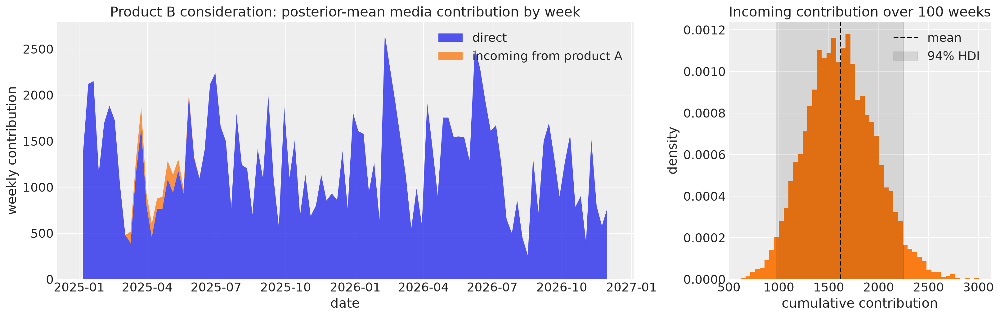

In [27]:
with spillover_model:
    spillover_predictions = pm.sample_posterior_predictive(
        spillover_idata, var_names=["total_media_contribution"], random_seed=seed
    )

product_b_total = spillover_predictions.posterior_predictive[
    "total_media_contribution"
].sel(product="product B", target="consideration", drop=True)
product_b_incoming = spillover_idata.posterior["spillover_contribution"].sel(
    product="product B", target="consideration", drop=True
)
product_b_direct = product_b_total - product_b_incoming
incoming_cumulative = product_b_incoming.sum("date")
incoming_cumulative_hdi = az.hdi(
    incoming_cumulative.to_dataset(name="incoming"), prob=HDI_PROB
)["incoming"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 5),
    gridspec_kw={"width_ratios": [2.2, 1]},
    layout="constrained",
)
axes[0].stackplot(
    dates,
    product_b_direct.mean(("chain", "draw")),
    product_b_incoming.mean(("chain", "draw")),
    labels=["direct", "incoming from product A"],
    colors=["C0", "C1"],
    alpha=0.8,
)
axes[0].set(
    title="Product B consideration: posterior-mean media contribution by week",
    xlabel="date",
    ylabel="weekly contribution",
)
axes[0].legend(loc="upper right")
axes[1].hist(incoming_cumulative.values.ravel(), bins=50, color="C1", density=True)
axes[1].axvline(
    incoming_cumulative.mean().item(), color="black", linestyle="--", label="mean"
)
axes[1].axvspan(
    incoming_cumulative_hdi.sel(ci_bound="lower").item(),
    incoming_cumulative_hdi.sel(ci_bound="upper").item(),
    color="black",
    alpha=0.1,
    label=f"{HDI_PROB:.0%} HDI",
)
axes[1].set(
    title="Incoming contribution over 100 weeks",
    xlabel="cumulative contribution",
    ylabel="density",
)
axes[1].legend(loc="upper right")

incoming_share = (incoming_cumulative / product_b_total.sum("date")).mean().item()
print(
    f"Incoming spillover: {incoming_cumulative.mean().item():,.0f} over 100 weeks "
    f"({HDI_PROB:.0%} HDI {incoming_cumulative_hdi.sel(ci_bound='lower').item():,.0f} to "
    f"{incoming_cumulative_hdi.sel(ci_bound='upper').item():,.0f}), "
    f"{incoming_share:.1%} of product B's consideration media contribution."
)

Over the $100$ weeks the model attributes $1{,}619$ units of product B's consideration to product A's media ($94\%$ HDI $978$ to $2{,}249$), which is $1.3\%$ of product B's total media contribution. The share is small because the two source channels only ran for ten weeks; at a constant weekly allocation the incoming part is proportionally larger, as we will see next.

## Optimize Total Consideration with Spillover

With spillover in the model, the best use of the budget for consideration changes: money on `out of home` and `social media` now counts for product A *and* for product B. We maximize the expected media-driven consideration summed over all three products, direct plus incoming, under the spillover posterior:

$$
\max_{b_c \geq 0}\;
\mathbb{E}\left[
\sum_{p}\Big(\sum_c f_{T,p,\text{consideration},c}(b) + S_{T,p,\text{consideration}}(b)\Big)
\right],
\qquad \sum_c b_c = 5{,}000,
$$

where $T$ is the final week of the steady-state horizon. We use `total_media_contribution` as the response variable, so the spillover is recomputed from the source contribution at every candidate allocation. The horizon, starts and solver settings are the same as before.

In [28]:
consideration_optimization_model = optimization_clone(spillover_model)


def expected_total_consideration(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return expected final-week consideration summed over products, spillover included."""
    return (
        samples.isel(date=-1, target=target_index["consideration"])
        .sum(dim="product")
        .mean(dim="sample")
    )


consideration_result, consideration_runs = maximize_utility(
    consideration_optimization_model,
    spillover_idata,
    "total_media_contribution",
    expected_total_consideration,
)
consideration_allocation = consideration_result.budgets.sel(channel=channels)
display(consideration_runs.round(1))
consideration_allocation.to_series().rename("weekly spend").to_frame().round(0)

,success,feasible,utility
start,,,
equal spend,True,True,8044.4
all out of home,True,True,8044.4
all TV,True,True,8044.4
all social media,True,True,8044.4
all search,True,True,8044.4
all display,True,True,8044.4


,weekly spend
channel,
out of home,639.0
TV,358.0
social media,545.0
search,1763.0
display,1695.0


### Two plans, one model

We now have two plans: the **balanced sales** plan chosen with the base model, and the **total consideration** plan chosen with the spillover model. To compare them fairly we score both under the same spillover posterior, draw by draw. The evaluator below computes each product's direct consideration, its incoming spillover from every source, and the total, from the closed-form steady-state response and the joint posterior of saturation parameters and shares.

In [29]:
consideration_maximum = unit_scale * spillover_idata.posterior["saturation_alpha"].sel(
    target="consideration", drop=True
)
consideration_half_saturation = unit_scale * spillover_idata.posterior[
    "saturation_lam"
].sel(target="consideration", drop=True)
consideration_path_share = spillover_idata.posterior["spillover_path_share"].sel(
    target="consideration", drop=True
)


def consideration_at(allocation: xr.DataArray) -> xr.Dataset:
    """Evaluate per-product steady-state consideration, direct and incoming, over posterior draws."""
    channel_direct = (
        consideration_maximum
        * allocation
        / (consideration_half_saturation + allocation)
    )
    direct = channel_direct.sum("channel")
    source = channel_direct.rename({"product": "source_product"})
    incoming = (consideration_path_share * source).sum(("source_product", "channel"))
    return xr.Dataset(
        {"direct": direct, "incoming": incoming, "total": direct + incoming}
    )


def summarize_draws(draws: xr.Dataset | xr.DataArray) -> pd.DataFrame:
    """Summarize posterior mean and HDI over (chain, draw) as a table."""
    if isinstance(draws, xr.DataArray):
        draws = draws.to_dataset(name=draws.name or "value")
    hdi = az.hdi(draws, prob=HDI_PROB)
    return (
        xr.Dataset(
            {
                "mean": draws.mean(("chain", "draw")).to_array("component"),
                "hdi lower": hdi.sel(ci_bound="lower", drop=True).to_array("component"),
                "hdi upper": hdi.sel(ci_bound="upper", drop=True).to_array("component"),
            }
        )
        .to_dataframe()
        .round(0)
    )


# The closed form must reproduce the optimizer's objective at its own solution.
np.testing.assert_allclose(
    consideration_at(consideration_allocation)["total"]
    .sum("product")
    .mean(("chain", "draw")),
    -consideration_result.scipy_result.fun,
    rtol=1e-6,
)

plan_names = ["Balanced sales", "Total consideration"]
plan_allocations = xr.concat(
    [weekly_allocation, consideration_allocation], dim="plan"
).assign_coords(plan=plan_names)
display(plan_allocations.to_pandas().round(0))
plan_consideration = consideration_at(plan_allocations).sum("product")
display(summarize_draws(plan_consideration))

plan_gain = plan_consideration.sel(
    plan="Total consideration", drop=True
) - plan_consideration.sel(plan="Balanced sales", drop=True)
gain_table = summarize_draws(plan_gain)
gain_table["P(gain > 0)"] = (
    (plan_gain > 0).mean(("chain", "draw")).to_array("component").to_series()
)
display(gain_table)

channel,out of home,TV,social media,search,display
plan,,,,,
Balanced sales,1260.0,1134.0,437.0,963.0,1206.0
Total consideration,639.0,358.0,545.0,1763.0,1695.0


mean  hdi lower  hdi upper
plan                component                              
Balanced sales      direct     7263.0     6495.0     8027.0
                    incoming    195.0      102.0      293.0
                    total      7457.0     6654.0     8241.0
Total consideration direct     7886.0     7193.0     8567.0
                    incoming    159.0       92.0      228.0
                    total      8044.0     7339.0     8754.0

,mean,hdi lower,hdi upper,P(gain > 0)
component,,,,
direct,623.0,422.0,817.0,1.000000
incoming,-36.0,-73.0,-0.0,0.012625
total,587.0,373.0,801.0,1.000000


The total-consideration plan moves about $1{,}400$ per week out of `out of home` and `TV` and into `search` and `display`, the channels with the largest consideration amplitudes for every product. Under the spillover posterior it delivers $8{,}044$ in weekly consideration across products against $7{,}457$ for the balanced plan, a gain of $587$ ($94\%$ HDI $373$ to $801$) that is positive in every posterior draw. The gain comes entirely from the direct response; the incoming spillover actually drops by $36$, because less money goes to the two channels that feed it. So even with a strong spillover prior, spillover does not change where the money goes; the direct curves dominate. Keep in mind that this compares two objectives as well as two models: it is the difference between two decisions scored under one posterior, not the value of adding spillover to an otherwise identical problem.

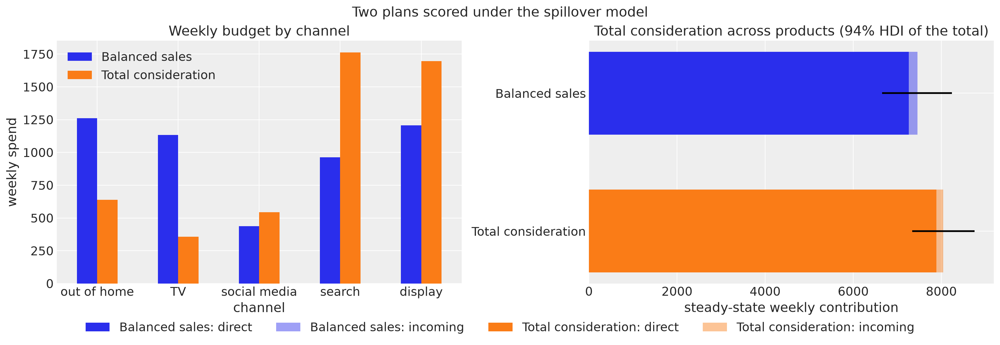

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5.5), layout="constrained")
plan_allocations.to_pandas().T.plot.bar(ax=axes[0], color=["C0", "C1"], rot=0)
axes[0].set(title="Weekly budget by channel", xlabel="channel", ylabel="weekly spend")
axes[0].legend(loc="upper left")

plan_means = plan_consideration.mean(("chain", "draw"))
plan_total_hdi = az.hdi(plan_consideration[["total"]], prob=HDI_PROB)["total"]
for row, (plan, color) in enumerate(zip(plan_names, ["C0", "C1"], strict=True)):
    direct = plan_means["direct"].sel(plan=plan).item()
    incoming = plan_means["incoming"].sel(plan=plan).item()
    axes[1].barh(row, direct, height=0.6, color=color, label=f"{plan}: direct")
    axes[1].barh(
        row,
        incoming,
        left=direct,
        height=0.6,
        color=color,
        alpha=0.45,
        label=f"{plan}: incoming",
    )
    axes[1].hlines(
        row,
        plan_total_hdi.sel(plan=plan, ci_bound="lower").item(),
        plan_total_hdi.sel(plan=plan, ci_bound="upper").item(),
        color="black",
        linewidth=2,
    )
axes[1].set(
    title=f"Total consideration across products ({HDI_PROB:.0%} HDI of the total)",
    xlabel="steady-state weekly contribution",
    yticks=range(len(plan_names)),
    yticklabels=plan_names,
)
axes[1].invert_yaxis()
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=4)
fig.suptitle("Two plans scored under the spillover model", fontsize=16);

## Goals Instead of a Budget

The last question turns the problem around. Instead of "what is the best use of $5{,}000$?", a stakeholder may ask "what is the least we can spend and still reach our goals for product B?". Following the target-seeking example in {ref}`mmm_budget_allocation_example`, we minimize weekly spend subject to two goals on expected outcomes and a spending cap:

$$
\min_{b_c \geq 0}\ \sum_c b_c
\qquad\text{s.t.}\qquad
\mathbb{E}[\text{sales}_{B}(b)] \geq g_{\text{sales}},
\qquad
\mathbb{E}[\text{consideration}_{B}(b)] \geq g_{\text{cons}},
\qquad
\sum_c b_c \leq \text{cap}.
$$

Both outcomes are media-driven contributions in the final week of the horizon under the spillover model, so consideration includes the incoming spillover. The goals constrain posterior means, not every draw.

To make the goals concrete we set them at $90\%$ of what the balanced sales plan delivers for product B, rounded down to the nearest hundred. The question is then: how much cheaper than $5{,}000$ can we get $90\%$ of that plan's product B outcomes?

In [31]:
product_b_sales_maximum = unit_scale * spillover_idata.posterior[
    "saturation_alpha"
].sel(product="product B", target="sales", drop=True)
product_b_sales_half_saturation = unit_scale * spillover_idata.posterior[
    "saturation_lam"
].sel(product="product B", target="sales", drop=True)


def product_b_outcomes_at(allocation: xr.DataArray) -> xr.Dataset:
    """Evaluate product B's steady-state sales and consideration (spillover included) over draws."""
    sales = (
        product_b_sales_maximum
        * allocation
        / (product_b_sales_half_saturation + allocation)
    ).sum("channel")
    consideration = consideration_at(allocation)["total"].sel(
        product="product B", drop=True
    )
    return xr.Dataset({"sales": sales, "consideration": consideration})


def round_down_to_hundreds(value: float) -> float:
    """Round a positive amount down to the nearest hundred."""
    return float(np.floor(value / 100.0) * 100.0)


balanced_product_b = product_b_outcomes_at(weekly_allocation).mean(("chain", "draw"))
sales_goal = round_down_to_hundreds(0.9 * balanced_product_b["sales"].item())
consideration_goal = round_down_to_hundreds(
    0.9 * balanced_product_b["consideration"].item()
)
print(
    f"Balanced plan, product B: sales {balanced_product_b['sales'].item():,.0f}, "
    f"consideration {balanced_product_b['consideration'].item():,.0f}."
)
print(f"Goals: sales >= {sales_goal:,.0f}, consideration >= {consideration_goal:,.0f}.")

Balanced plan, product B: sales 4,850, consideration 2,084.
Goals: sales >= 4,300, consideration >= 1,800.


The optimizer takes the goals as `Constraint` objects. Passing any custom constraint switches off the default "spend the whole budget" constraint, which is what we want here: the cap is a ceiling, not an amount to spend. The utility is minus the total spend. We also build a second optimizer that *maximizes* product B's sales under the consideration goal and the cap; its optimum tells us whether the sales goal is reachable at all, and gives a feasible starting point for the minimum-spend problem.

In [32]:
goal_tolerance = 1e-7 * unit_scale


def expected_product_b_sales(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return product B's expected final-week sales."""
    return samples.isel(
        date=-1, product=product_index["product B"], target=target_index["sales"]
    ).mean(dim="sample")


def expected_product_b_consideration(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return product B's expected final-week consideration, spillover included."""
    return samples.isel(
        date=-1,
        product=product_index["product B"],
        target=target_index["consideration"],
    ).mean(dim="sample")


def minimum_spend(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return minus the weekly spend, so that maximizing it minimizes spend."""
    return -budgets.sum(dim="channel")


def cap_constraint(budgets_sym, total_budget_sym, optimizer) -> XTensorVariable:
    """Keep weekly spend at or below the cap (``total_budget``)."""
    return total_budget_sym - budgets_sym.sum(dim="channel")


def consideration_goal_constraint(
    budgets_sym, total_budget_sym, optimizer
) -> XTensorVariable:
    """Require expected product B consideration to reach the goal."""
    response = optimizer.extract_response_distribution("total_media_contribution")
    return expected_product_b_consideration(response, budgets_sym) - consideration_goal


def sales_goal_constraint(budgets_sym, total_budget_sym, optimizer) -> XTensorVariable:
    """Require expected product B sales to reach the goal."""
    response = optimizer.extract_response_distribution("total_media_contribution")
    return expected_product_b_sales(response, budgets_sym) - sales_goal


goal_optimizer_settings = {
    "model": consideration_optimization_model,
    "idata": spillover_idata,
    "num_periods": optimization_horizon,
    "response_variable": "total_media_contribution",
}
cap_and_consideration_constraints = [
    Constraint(key="cap", constraint_type="ineq", constraint_fun=cap_constraint),
    Constraint(
        key="consideration goal",
        constraint_type="ineq",
        constraint_fun=consideration_goal_constraint,
    ),
]
reachable_sales_optimizer = BudgetOptimizer(
    **goal_optimizer_settings,
    utility_function=expected_product_b_sales,
    constraints=cap_and_consideration_constraints,
)
minimum_spend_optimizer = BudgetOptimizer(
    **goal_optimizer_settings,
    utility_function=minimum_spend,
    constraints=[
        *cap_and_consideration_constraints,
        Constraint(
            key="sales goal",
            constraint_type="ineq",
            constraint_fun=sales_goal_constraint,
        ),
    ],
)


def cheapest_plan(cap: float) -> dict:
    """Find the minimum spend reaching both goals under a cap, or report why it cannot be reached."""
    bounds = {channel: (0.0, cap) for channel in channels}
    starts = starting_allocations * cap / weekly_budget
    reachable_runs = [
        reachable_sales_optimizer.allocate_budget(
            total_budget=cap,
            budget_bounds=bounds,
            x0=start,
            minimize_kwargs=minimize_kwargs,
            return_if_fail=True,
        )
        for start in starts
    ]
    reachable_runs = [run for run in reachable_runs if run.scipy_result.success]
    record = {
        "cap": cap,
        "reachable sales": np.nan,
        "spend": np.nan,
        "allocation": None,
    }
    if not reachable_runs:
        record["status"] = "consideration goal not reachable under the cap"
        return record
    best_reachable = min(reachable_runs, key=lambda run: run.scipy_result.fun)
    record["reachable sales"] = -best_reachable.scipy_result.fun
    if record["reachable sales"] < sales_goal - goal_tolerance:
        record["status"] = "sales goal not reachable under the cap"
        return record
    runs = [
        minimum_spend_optimizer.allocate_budget(
            total_budget=cap,
            budget_bounds=bounds,
            x0=start,
            minimize_kwargs=minimize_kwargs,
            return_if_fail=True,
        )
        for start in [*starts, best_reachable.budgets.values]
    ]
    runs = [run for run in runs if run.scipy_result.success]
    if not runs:
        raise RuntimeError(f"No minimum-spend run converged for cap {cap:,.0f}.")
    best = min(runs, key=lambda run: run.scipy_result.fun)
    record.update(
        status="both goals reached",
        spend=best.scipy_result.fun,
        allocation=best.budgets.sel(channel=channels),
    )
    return record

We solve it twice. First with a loose cap of $10{,}000$, which should not bind. Then with a tight cap set well below the cheapest plan we just found, to see how the optimizer reports a goal that cannot be met.

In [33]:
loose_cap = 10.0 * unit_scale
loose = cheapest_plan(loose_cap)
tight_cap = round_down_to_hundreds(0.6 * loose["spend"])
tight = cheapest_plan(tight_cap)
goal_scenarios = pd.DataFrame(
    [
        {key: value for key, value in scenario.items() if key != "allocation"}
        for scenario in (loose, tight)
    ],
    index=pd.Index(["loose cap", "tight cap"], name="scenario"),
)
goal_scenarios["sales goal"] = sales_goal
display(goal_scenarios.round(0))
cheapest_allocation = loose["allocation"]
cheapest_allocation.to_series().rename("weekly spend").to_frame().round(0)

,cap,reachable sales,spend,status,sales goal
scenario,,,,,
loose cap,10000.0,6604.0,2708.0,both goals reached,4300.0
tight cap,1600.0,NaN,NaN,consideration goal not reachable under the cap,4300.0


,weekly spend
channel,
out of home,213.0
TV,18.0
social media,40.0
search,1527.0
display,910.0


Under the loose cap the cheapest plan spends $2{,}708$ per week, $46\%$ less than the balanced plan's $5{,}000$, and reaches both goals. Almost all of it goes to `search` ($1{,}527$) and `display` ($910$), product B's own sales channels, with $213$ on `out of home`, which also feeds product B's consideration through spillover, and next to nothing on `TV` and `social media`. The consideration goal is the binding one: the plan lands exactly on $1{,}800$ and slightly above the sales goal. With the tight cap of $1{,}600$ the feasibility step reports that the consideration goal itself cannot be reached, so there is no plan to show; at that budget the stakeholder has to relax a goal or the cap.

### Three plans for product B

Finally we score the three plans on product B's outcomes under the spillover model. The histograms show the posterior of each outcome under each plan with the goals as dashed lines. The cheapest plan sits on the consideration goal *on average*, which means about half of the posterior draws fall short of it; the fraction of draws meeting both goals is in the last table. If that is not acceptable, the goals should be set on a quantile rather than on the mean.

In [34]:
all_plan_names = [*plan_names, "Cheapest for product B goals"]
all_allocations = xr.concat(
    [weekly_allocation, consideration_allocation, cheapest_allocation], dim="plan"
).assign_coords(plan=all_plan_names)
product_b_draws = product_b_outcomes_at(all_allocations)
product_b_table = summarize_draws(product_b_draws)
both_goals_probability = (
    (
        (product_b_draws["sales"] >= sales_goal)
        & (product_b_draws["consideration"] >= consideration_goal)
    )
    .mean(("chain", "draw"))
    .to_series()
    .rename("P(both goals)")
    .to_frame()
)
display(all_allocations.to_pandas().round(0))
display(product_b_table)
display(both_goals_probability.round(2))

# The cheapest plan must meet both goals in expectation, within the solver tolerance.
cheapest_means = product_b_draws.sel(plan=all_plan_names[-1]).mean(("chain", "draw"))
if (
    cheapest_means["sales"].item() < sales_goal - goal_tolerance
    or cheapest_means["consideration"].item() < consideration_goal - goal_tolerance
):
    raise RuntimeError("The cheapest plan violates a goal.")

channel,out of home,TV,social media,search,display
plan,,,,,
Balanced sales,1260.0,1134.0,437.0,963.0,1206.0
Total consideration,639.0,358.0,545.0,1763.0,1695.0
Cheapest for product B goals,213.0,18.0,40.0,1527.0,910.0


mean  hdi lower  hdi upper
plan                         component                                  
Balanced sales               sales          4850.0     4431.0     5269.0
                             consideration  2084.0     1846.0     2338.0
Total consideration          sales          5413.0     5050.0     5777.0
                             consideration  2371.0     2158.0     2588.0
Cheapest for product B goals sales          4331.0     4019.0     4646.0
                             consideration  1800.0     1646.0     1962.0

,P(both goals)
plan,
Balanced sales,0.99
Total consideration,1.00
Cheapest for product B goals,0.28


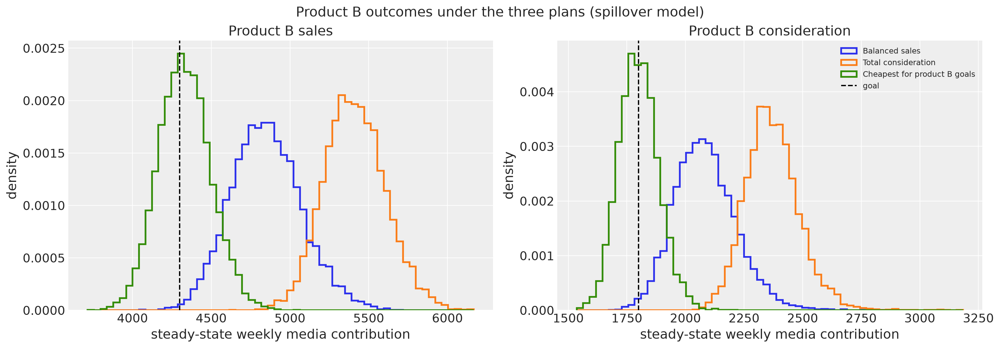

In [35]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5.5), layout="constrained")
goals = {"sales": sales_goal, "consideration": consideration_goal}
for ax, outcome in zip(axes, ["sales", "consideration"], strict=True):
    draws = product_b_draws[outcome]
    bins = np.histogram_bin_edges(draws.values.ravel(), bins=60)
    for plan, color in zip(all_plan_names, ["C0", "C1", "C2"], strict=True):
        plan_draws = draws.sel(plan=plan).values.ravel()
        ax.hist(
            plan_draws,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=2,
            color=color,
            label=plan,
        )
    ax.axvline(goals[outcome], color="black", linestyle="--", label="goal")
    ax.set(
        title=f"Product B {outcome}",
        xlabel="steady-state weekly media contribution",
        ylabel="density",
    )
axes[1].legend(loc="upper right", fontsize=9)
fig.suptitle("Product B outcomes under the three plans (spillover model)", fontsize=16);

The balanced plan gives product B $4{,}850$ in sales and $2{,}084$ in consideration and meets both goals in $99\%$ of the draws; the total-consideration plan gives it more of both ($5{,}413$ and $2{,}371$) because product B's channels are also the consideration channels. The cheapest plan meets both goals on average but only in $28\%$ of the draws, which is the price of spending $46\%$ less.

## Conclusion

One shared media budget, three products, and channels that favor different products: there is no single optimal plan, only trade-offs. This notebook showed how to make those trade-offs explicit and how to choose among them with the fitted model.

**Key findings**

- With the true parameters, the sales frontier is strongly curved and the max-min plan gives every product $81.5\%$ of its own best. Consideration conflicts much less, $97.3\%$, because all products respond to `search` and `display`.
- The fitted model recovers the channel contributions. Under the posterior, the single-product sales plans leave the other product at $20\%$ to $41\%$ of its potential; the balanced plan lifts all three products to $88\%$ at a cost of about $12\%$ of each product's best sales and $7\%$ of the best total consideration.
- `Total consideration` and `Total brand` are interchangeable in practice: both totals differ by less than $1\%$, even though brand is estimated from data with twice the noise.
- Under the spillover model the total-consideration plan gains $587$ in weekly consideration ($94\%$ HDI $373$ to $801$) over the balanced plan. The gain is all direct response; the incoming spillover even drops a little, because the direct curves, not the spillover, decide where the money goes.
- The cheapest plan that reaches $90\%$ of the balanced plan's product B outcomes spends $2{,}708$ per week, $46\%$ less, but meets both goals in only $28\%$ of the draws. With a cap of $1{,}600$ the goals are out of reach.

**Limitations**

- The spillover shares are driven by a deliberately strong prior. With shared spend, the data cannot separate direct response from spillover; a real analysis needs product-specific spend, experiments, or a prior justified elsewhere.
- All objectives and goals are posterior means. The max-min rule protects the average worst-off product, and the goal-seeking plan meets its goals on average, not with high probability. {ref}`mmm_allocation_assessment` shows how to bring risk into the objective.
- The plans are steady-state plans for a constant weekly allocation. They ignore the historical carry-over at the start of the horizon and any seasonality or trend.

**Next steps**

- Replace the max-min rule with the weights a stakeholder can defend, and show the resulting point on the frontier.
- Set the goals on a quantile of the posterior instead of the mean and re-solve the minimum-spend problem.
- Add a shared cap per channel, or minimum spends for committed contracts, as further `Constraint` objects.

In [36]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor,nutpie

Last updated: Mon, 28 Sep 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.3.2
nutpie        : 0.16.11

arviz         : 1.2.0
arviz_plots   : 1.2.0
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 3.0.5
pymc          : 6.3.2
pymc_extras   : 0.15.1
pymc_marketing: 1.1.0
pytensor      : 3.3.2
scipy         : 1.15.3
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

